# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')


#### **1.1.1**
Load the dataset

In [ ]:
# Load the data

from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Car_Price_data.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (15915, 23)

First Few Rows:
  make_model body_type  price               vat       km  Type     Fuel  \
0    Audi A1    Sedans  15770    VAT deductible  56013.0  Used   Diesel   
1    Audi A1    Sedans  14500  Price negotiable  80000.0  Used  Benzine   
2    Audi A1    Sedans  14640    VAT deductible  83450.0  Used   Diesel   
3    Audi A1    Sedans  14500    VAT deductible  73000.0  Used   Diesel   
4    Audi A1    Sedans  16790    VAT deductible  16200.0  Used   Diesel   

   Gears                                Comfort_Convenience  \
0    7.0  Air conditioning,Armrest,Automatic climate con...   
1    7.0  Air conditioning,Automatic climate control,Hil...   
2    7.0  Air conditioning,Cruise control,Electrical sid...   
3    6.0  Air suspension,Armrest,Auxiliary heating,Elect...   
4    7.0  Air conditioning,Armrest,Automatic climate con...  

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [ ]:
# Find the proportion of missing values in each column and handle if found
# Calculate missing value proportions
missing_props = df.isnull().sum() / len(df) * 100
missing_df = pd.DataFrame({
    'Column': missing_props.index,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': missing_props.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("\nMissing Values Summary:")
print(missing_df)

# Handle missing values
if missing_df.shape[0] > 0:
    for col in missing_df['Column']:
        if df[col].dtype in ['float64', 'int64']:
            # Fill numerical with median
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Fill categorical with mode
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("\nMissing values handled successfully")
else:
    print("\nNo missing values found")


Missing Values Summary:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

No missing values found


**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.


Numerical Features (9):
['km', 'Gears', 'age', 'Previous_Owners', 'hp_kW', 'Inspection_new', 'Displacement_cc', 'Weight_kg', 'cons_comb']

Numerical feature distributions plotted


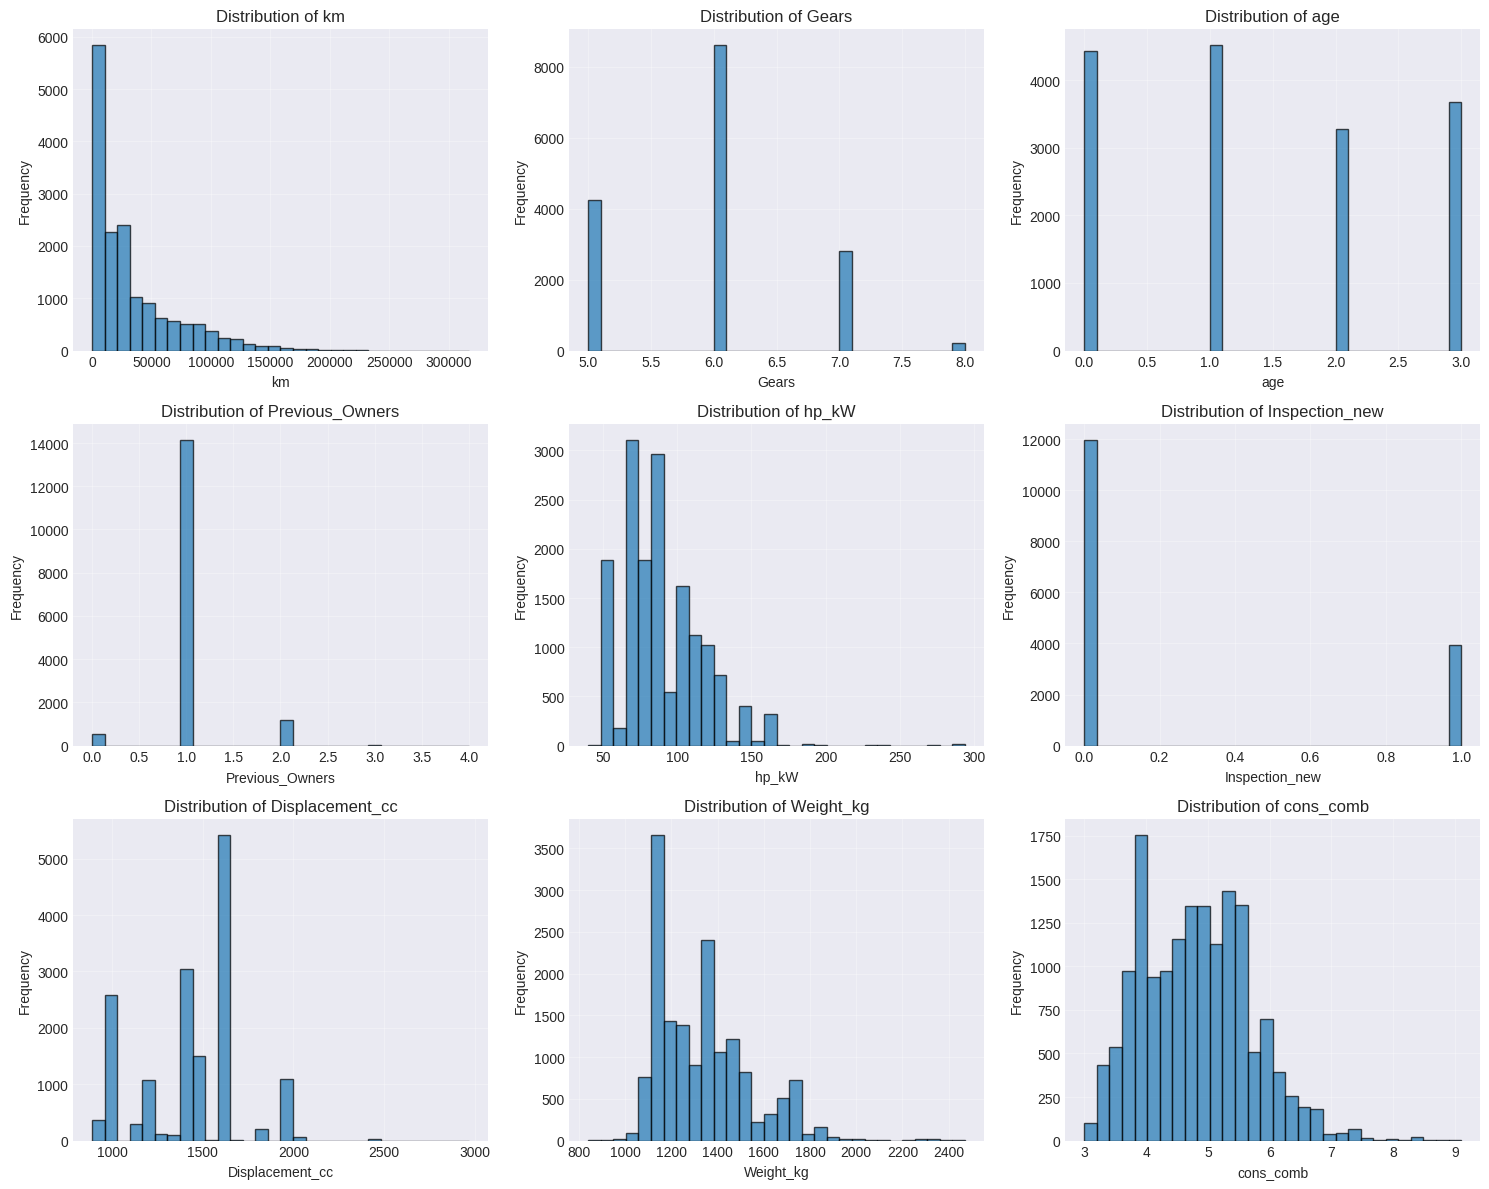

In [ ]:
# Identify numerical features and plot histograms
# Identify numerical columns (exclude target 'price')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'price' in numerical_cols:
    numerical_cols.remove('price')

print(f"\nNumerical Features ({len(numerical_cols)}):")
print(numerical_cols)

# Plot histograms for numerical features
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=300, bbox_inches='tight')
print("\nNumerical feature distributions plotted")

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.


Categorical Features (9):
['make_model', 'body_type', 'vat', 'Type', 'Fuel', 'Paint_Type', 'Upholstery_type', 'Gearing_Type', 'Drive_chain']

make_model - Value Counts:
make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64
Unique values: 9

body_type - Value Counts:
body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8
Name: count, dtype: int64
Unique values: 8

vat - Value Counts:
vat
VAT deductible      15044
Price negotiable      871
Name: count, dtype: int64
Unique values: 2

Type - Value Counts:
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64
Unique values: 5

Fu

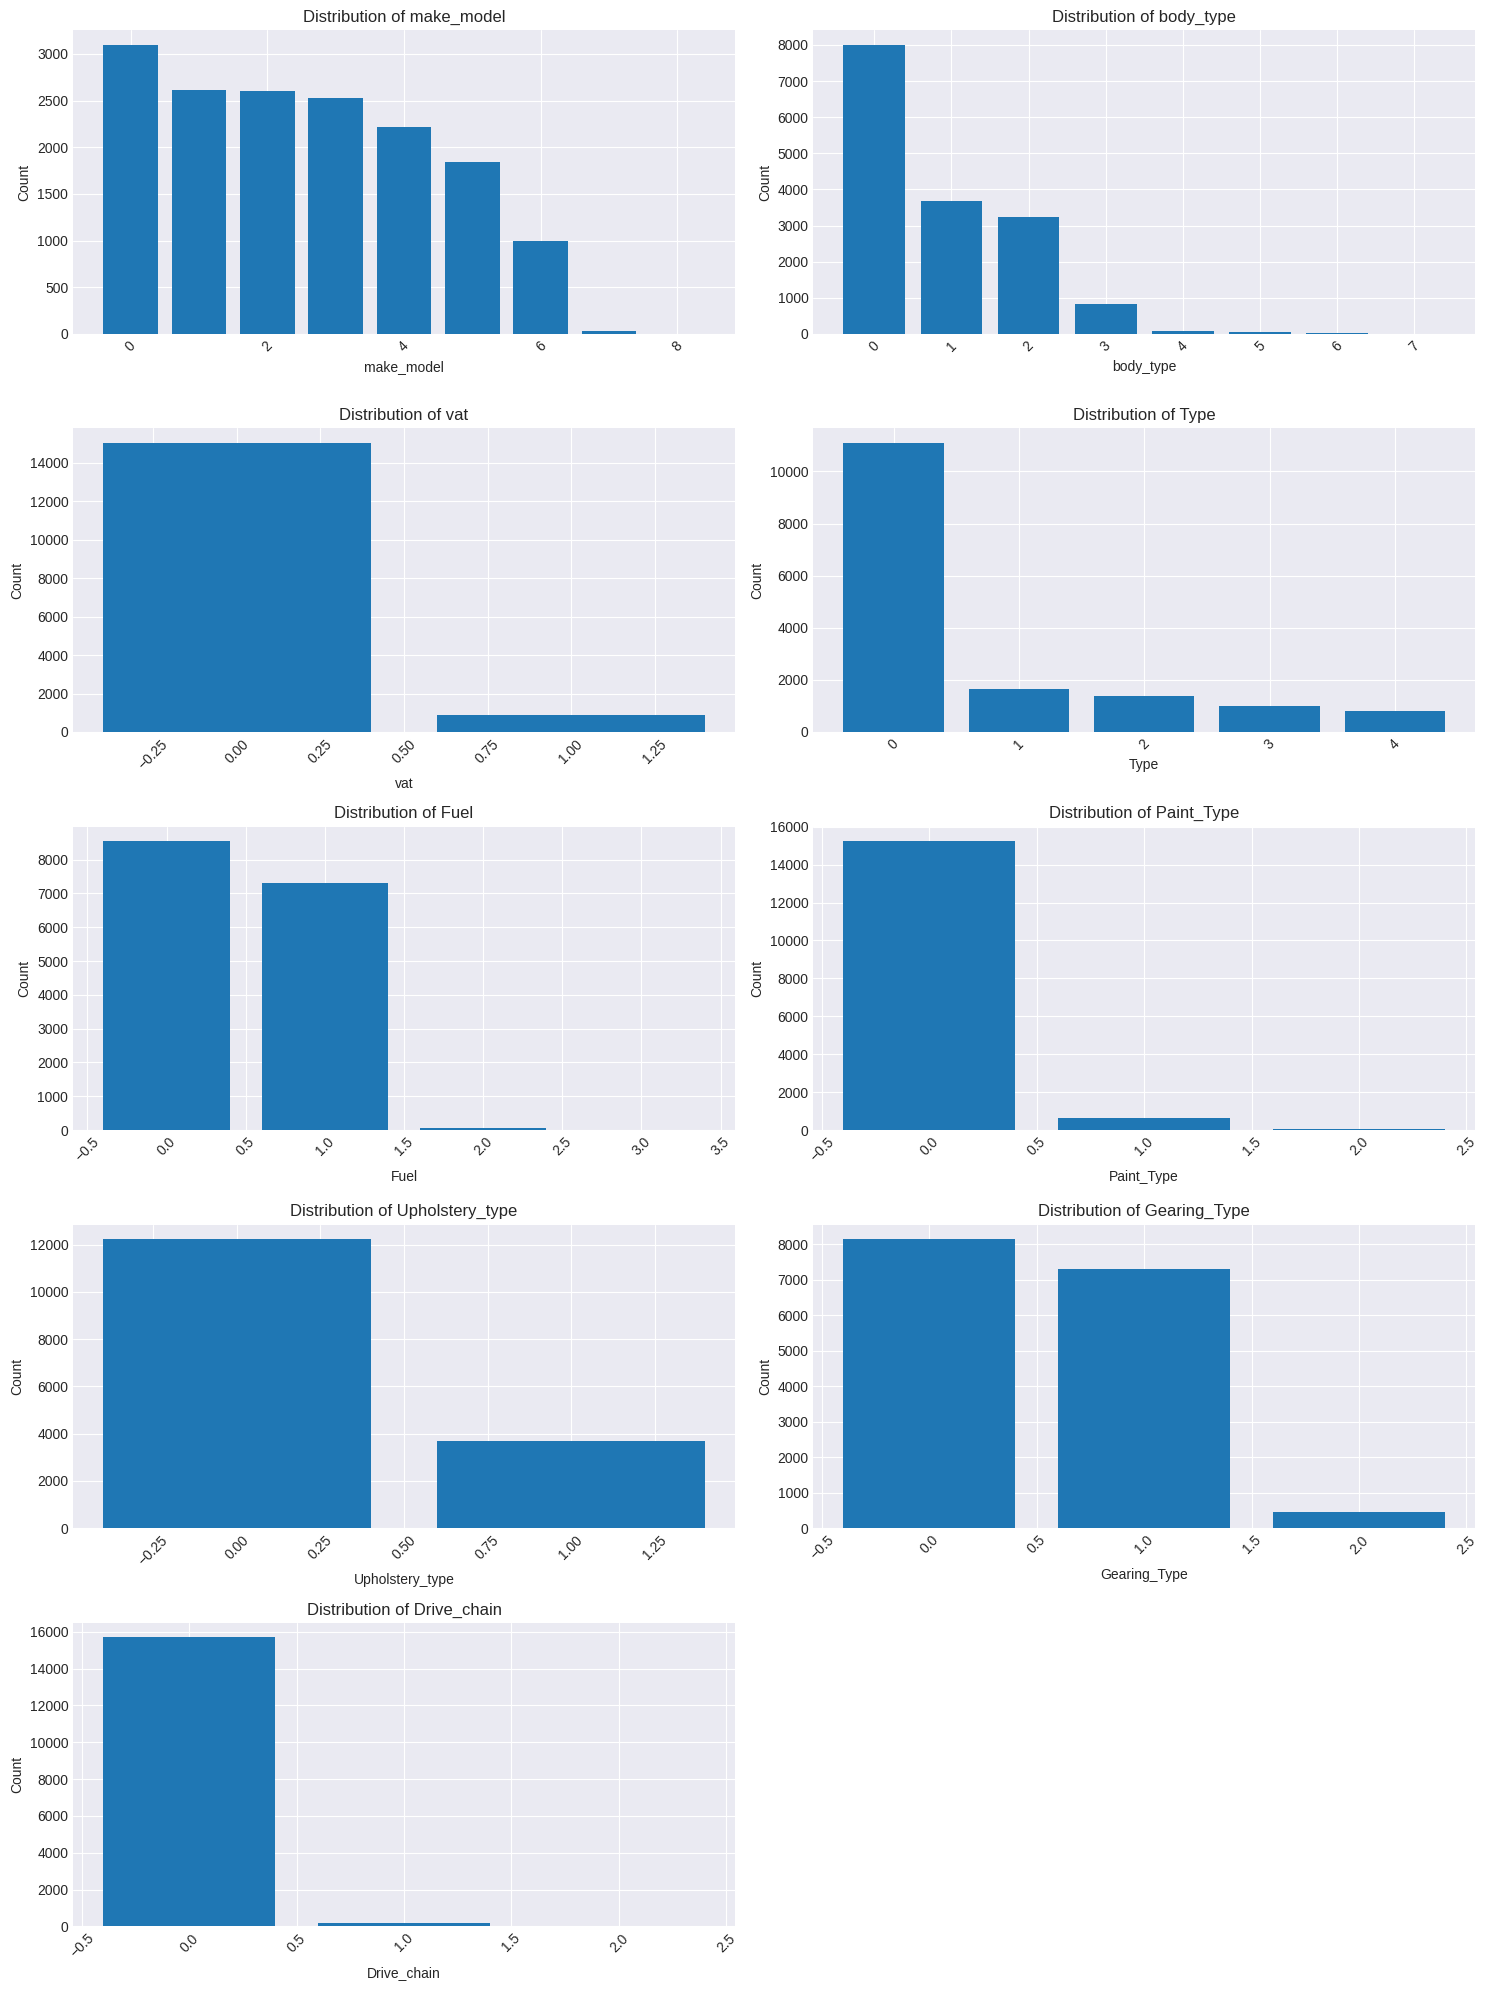

In [ ]:
# Identify categorical columns and check their frequency distributions
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove feature list columns that need special handling
special_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']
categorical_cols = [col for col in categorical_cols if col not in special_cols]

print(f"\nCategorical Features ({len(categorical_cols)}):")
print(categorical_cols)

# Check frequency distributions
for col in categorical_cols:
    print(f"\n{col} - Value Counts:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

# Plot categorical distributions
n_cols_cat = 2
n_rows_cat = (len(categorical_cols) + n_cols_cat - 1) // n_cols_cat
fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(15, n_rows_cat*4))
if n_rows_cat == 1:
    axes = [axes]
axes = np.array(axes).flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    if len(value_counts) > 15:
        value_counts = value_counts.head(15)
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
print("\nCategorical feature distributions plotted")

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [ ]:
# Fix columns as needed
# Handle 'Type' column - combine similar categories
if 'Type' in df.columns:
    print("\nOriginal Type distribution:")
    print(df['Type'].value_counts())

    # Combine Pre-registered, Employee's car, and Demonstration into 'Used'
    type_mapping = {
        'Pre-registered': 'Used',
        "Employee's car": 'Used',
        'Demonstration': 'Used',
        'New': 'New',
        'Used': 'Used'
    }
    df['Type'] = df['Type'].map(type_mapping)

    print("\nUpdated Type distribution:")
    print(df['Type'].value_counts())

# Handle other categorical columns with low frequency
threshold = 0.05  # 5% threshold
for col in categorical_cols:
    if col != 'Type':
        value_counts = df[col].value_counts(normalize=True)
        low_freq_values = value_counts[value_counts < threshold].index.tolist()

        if low_freq_values:
            print(f"\n{col} - Combining {len(low_freq_values)} low frequency categories into 'Other'")
            df[col] = df[col].apply(lambda x: 'Other' if x in low_freq_values else x)

print("\nLow frequency values handled")



Original Type distribution:
Type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

Updated Type distribution:
Type
Used    14266
New      1649
Name: count, dtype: int64

make_model - Combining 2 low frequency categories into 'Other'

body_type - Combining 4 low frequency categories into 'Other'

Fuel - Combining 2 low frequency categories into 'Other'

Paint_Type - Combining 2 low frequency categories into 'Other'

Gearing_Type - Combining 1 low frequency categories into 'Other'

Drive_chain - Combining 2 low frequency categories into 'Other'

Low frequency values handled


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.


Target Variable: price
Skewness: 1.236
Kurtosis: 2.966


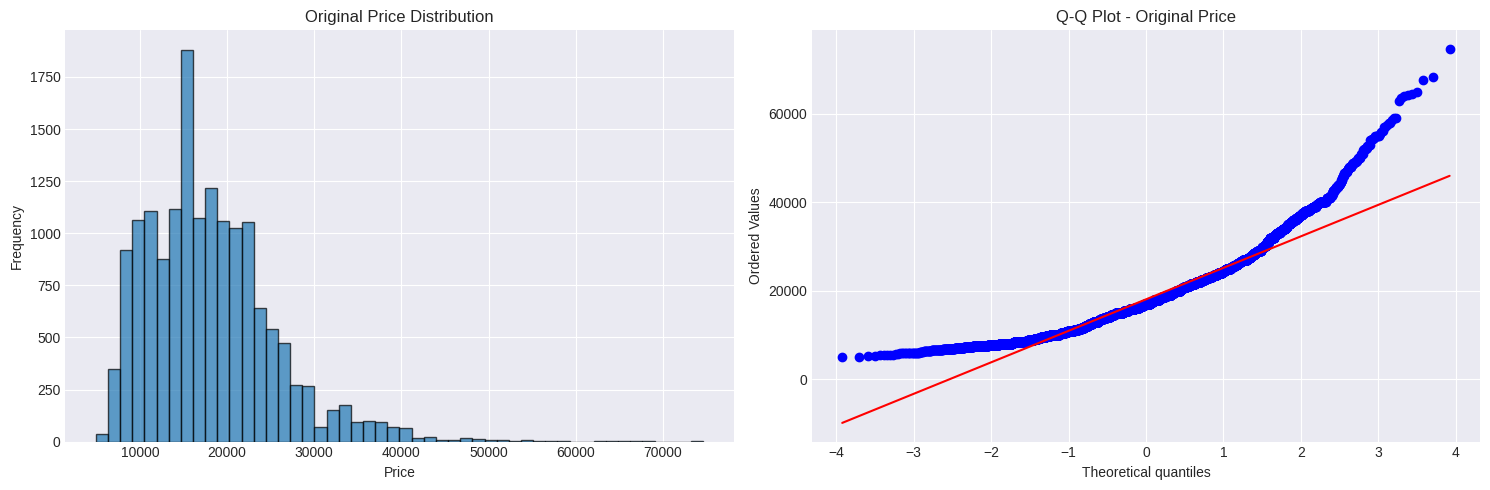

In [ ]:
# Plot histograms for target feature
target = 'price'

# Plot original target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df[target], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Q-Q plot for normality check
stats.probplot(df[target], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot - Original Price')

plt.tight_layout()
plt.savefig('target_original_distribution.png', dpi=300, bbox_inches='tight')

print(f"\nTarget Variable: {target}")
print(f"Skewness: {df[target].skew():.3f}")
print(f"Kurtosis: {df[target].kurtosis():.3f}")

**The target variable seems to be skewed. Perform suitable transformation on the target.**


After Log Transformation:
Skewness: -0.031
Kurtosis: -0.240

Target variable transformed successfully


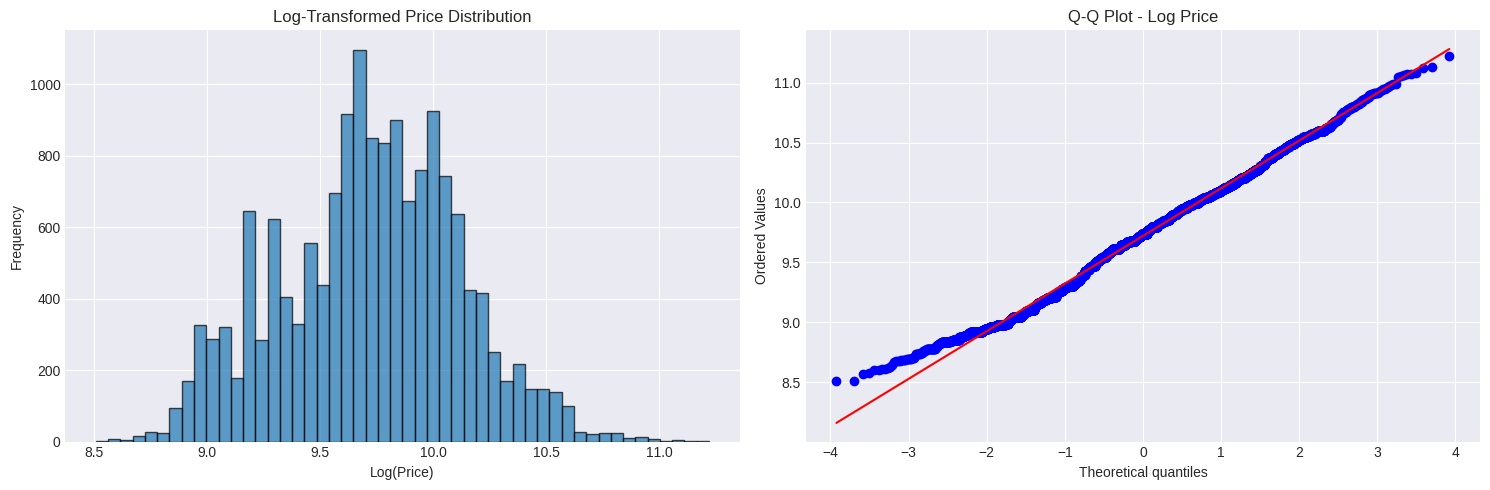

In [ ]:
# Transform the target feature

# Apply log transformation to reduce skewness
df['log_price'] = np.log1p(df[target])

# Plot transformed target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Log-Transformed Price Distribution')
axes[0].set_xlabel('Log(Price)')
axes[0].set_ylabel('Frequency')

stats.probplot(df['log_price'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot - Log Price')

plt.tight_layout()
plt.savefig('target_transformed_distribution.png', dpi=300, bbox_inches='tight')

print(f"\nAfter Log Transformation:")
print(f"Skewness: {df['log_price'].skew():.3f}")
print(f"Kurtosis: {df['log_price'].kurtosis():.3f}")
print("\nTarget variable transformed successfully")

# Update target variable
target = 'log_price'

### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.


Correlations with Target (log_price):
log_price          1.000000
hp_kW              0.678024
Gears              0.588194
Weight_kg          0.464597
Displacement_cc    0.254854
cons_comb          0.211097
Inspection_new     0.030927
Previous_Owners   -0.152029
km                -0.419189
age               -0.474618
Name: log_price, dtype: float64

Correlation analysis completed


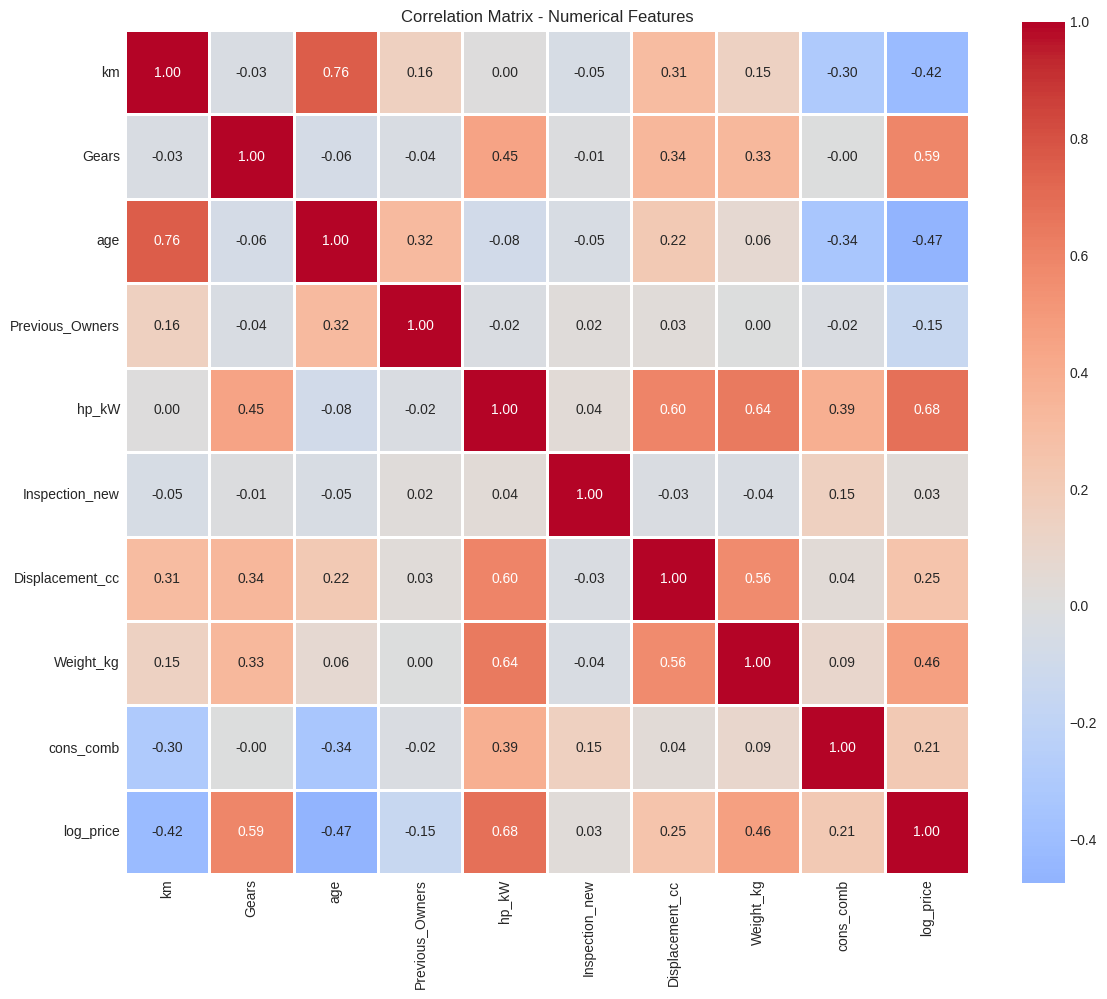

In [ ]:
# Visualise correlation

# Select numerical columns including target
numerical_cols_with_target = numerical_cols + [target]
correlation_df = df[numerical_cols_with_target].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

# Show correlations with target
target_corr = correlation_df[target].sort_values(ascending=False)
print("\nCorrelations with Target (log_price):")
print(target_corr)

print("\nCorrelation analysis completed")

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.


make_model - Average Price by Category:
make_model
Renault Espace    10.271724
Audi A3            9.928165
Opel Insignia      9.912658
Audi A1            9.817643
Opel Astra         9.626041
Other              9.504893
Renault Clio       9.335822
Opel Corsa         9.276059
Name: log_price, dtype: float64

body_type - Average Price by Category:
body_type
Van              10.294540
Station wagon     9.753456
Sedans            9.716144
Other             9.622932
Compact           9.555735
Name: log_price, dtype: float64

vat - Average Price by Category:
vat
VAT deductible      9.730286
Price negotiable    9.556299
Name: log_price, dtype: float64

Type - Average Price by Category:
Type
New     10.013453
Used     9.686932
Name: log_price, dtype: float64

Fuel - Average Price by Category:
Fuel
Diesel     9.734926
Benzine    9.709328
Other      9.639463
Name: log_price, dtype: float64

Paint_Type - Average Price by Category:
Paint_Type
Metallic    9.725404
Other       9.615009
Name: log_pri

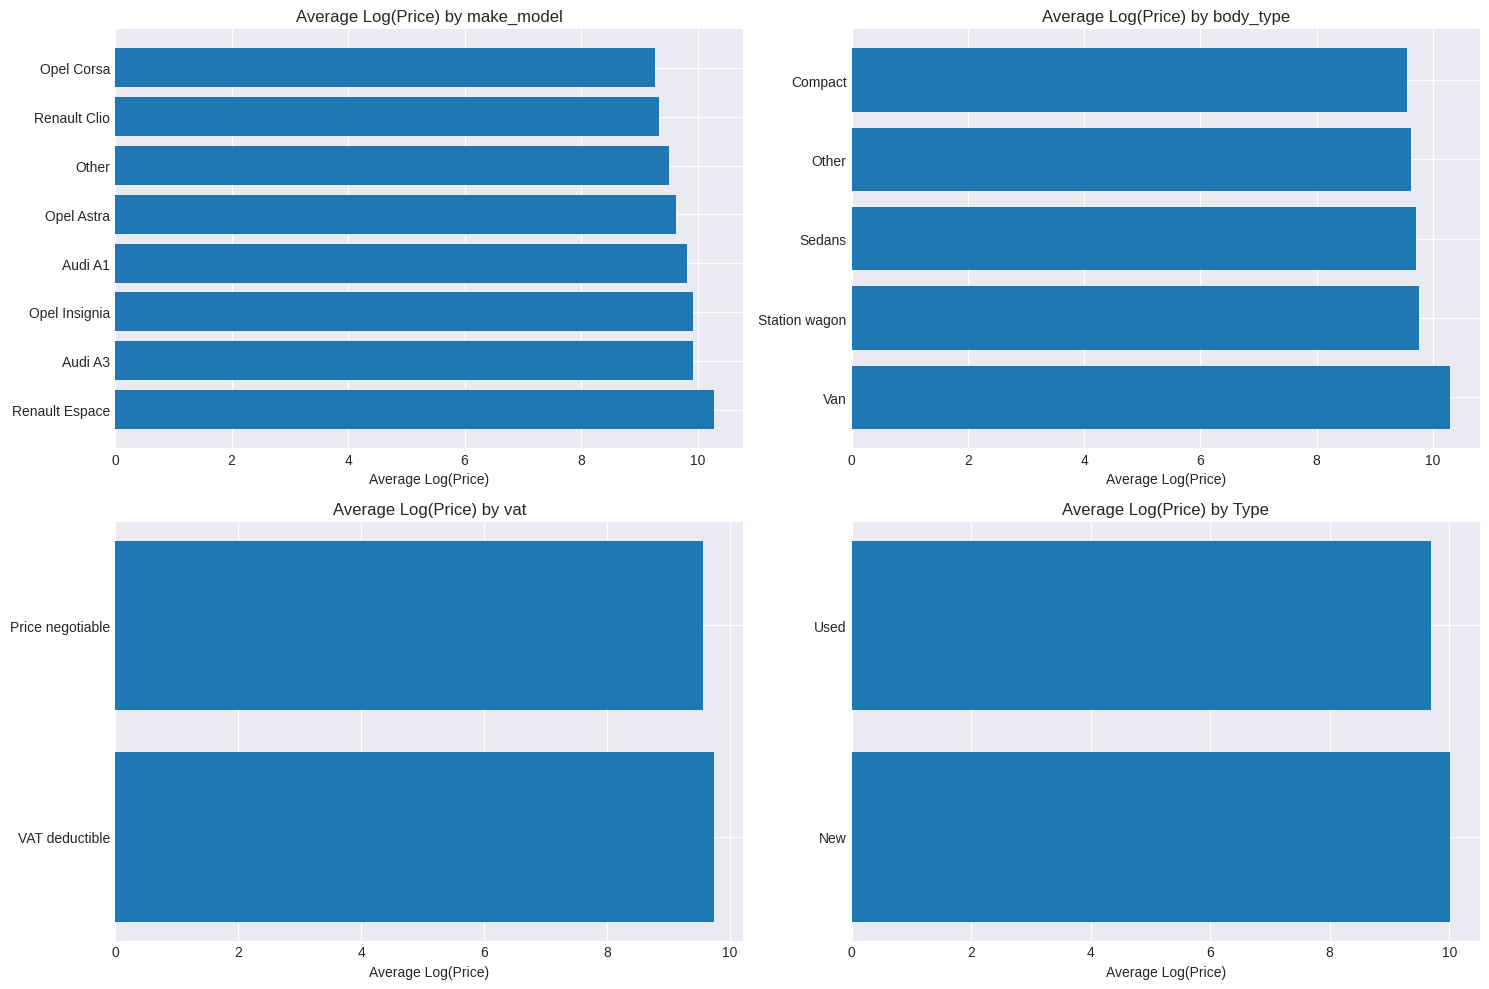

In [ ]:
# Comparing average values of target for different categories

# Analyze categorical features against target
for col in categorical_cols:
    print(f"\n{col} - Average Price by Category:")
    avg_price = df.groupby(col)[target].mean().sort_values(ascending=False)
    print(avg_price)

# Visualize top categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols[:4]):
    avg_price = df.groupby(col)[target].mean().sort_values(ascending=False)
    if len(avg_price) > 10:
        avg_price = avg_price.head(10)

    axes[idx].barh(range(len(avg_price)), avg_price.values)
    axes[idx].set_yticks(range(len(avg_price)))
    axes[idx].set_yticklabels(avg_price.index)
    axes[idx].set_title(f'Average Log(Price) by {col}')
    axes[idx].set_xlabel('Average Log(Price)')

plt.tight_layout()
plt.savefig('categorical_vs_target.png', dpi=300, bbox_inches='tight')
print("\nCategorical analysis completed")

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.


Outliers Summary:

km:
  Outliers: 689 (4.33%)
  Lower bound: -65548.75
  Upper bound: 114369.25

Gears:
  Outliers: 225 (1.41%)
  Lower bound: 3.50
  Upper bound: 7.50

age:
  Outliers: 0 (0.00%)
  Lower bound: -3.00
  Upper bound: 5.00

Previous_Owners:
  Outliers: 1757 (11.04%)
  Lower bound: 1.00
  Upper bound: 1.00

hp_kW:
  Outliers: 361 (2.27%)
  Lower bound: 10.50
  Upper bound: 158.50

Inspection_new:
  Outliers: 3932 (24.71%)
  Lower bound: 0.00
  Upper bound: 0.00

Displacement_cc:
  Outliers: 21 (0.13%)
  Lower bound: 675.50
  Upper bound: 2151.50

Weight_kg:
  Outliers: 87 (0.55%)
  Lower bound: 704.50
  Upper bound: 1932.50

cons_comb:
  Outliers: 125 (0.79%)
  Lower bound: 2.15
  Upper bound: 7.35

Outlier identification completed


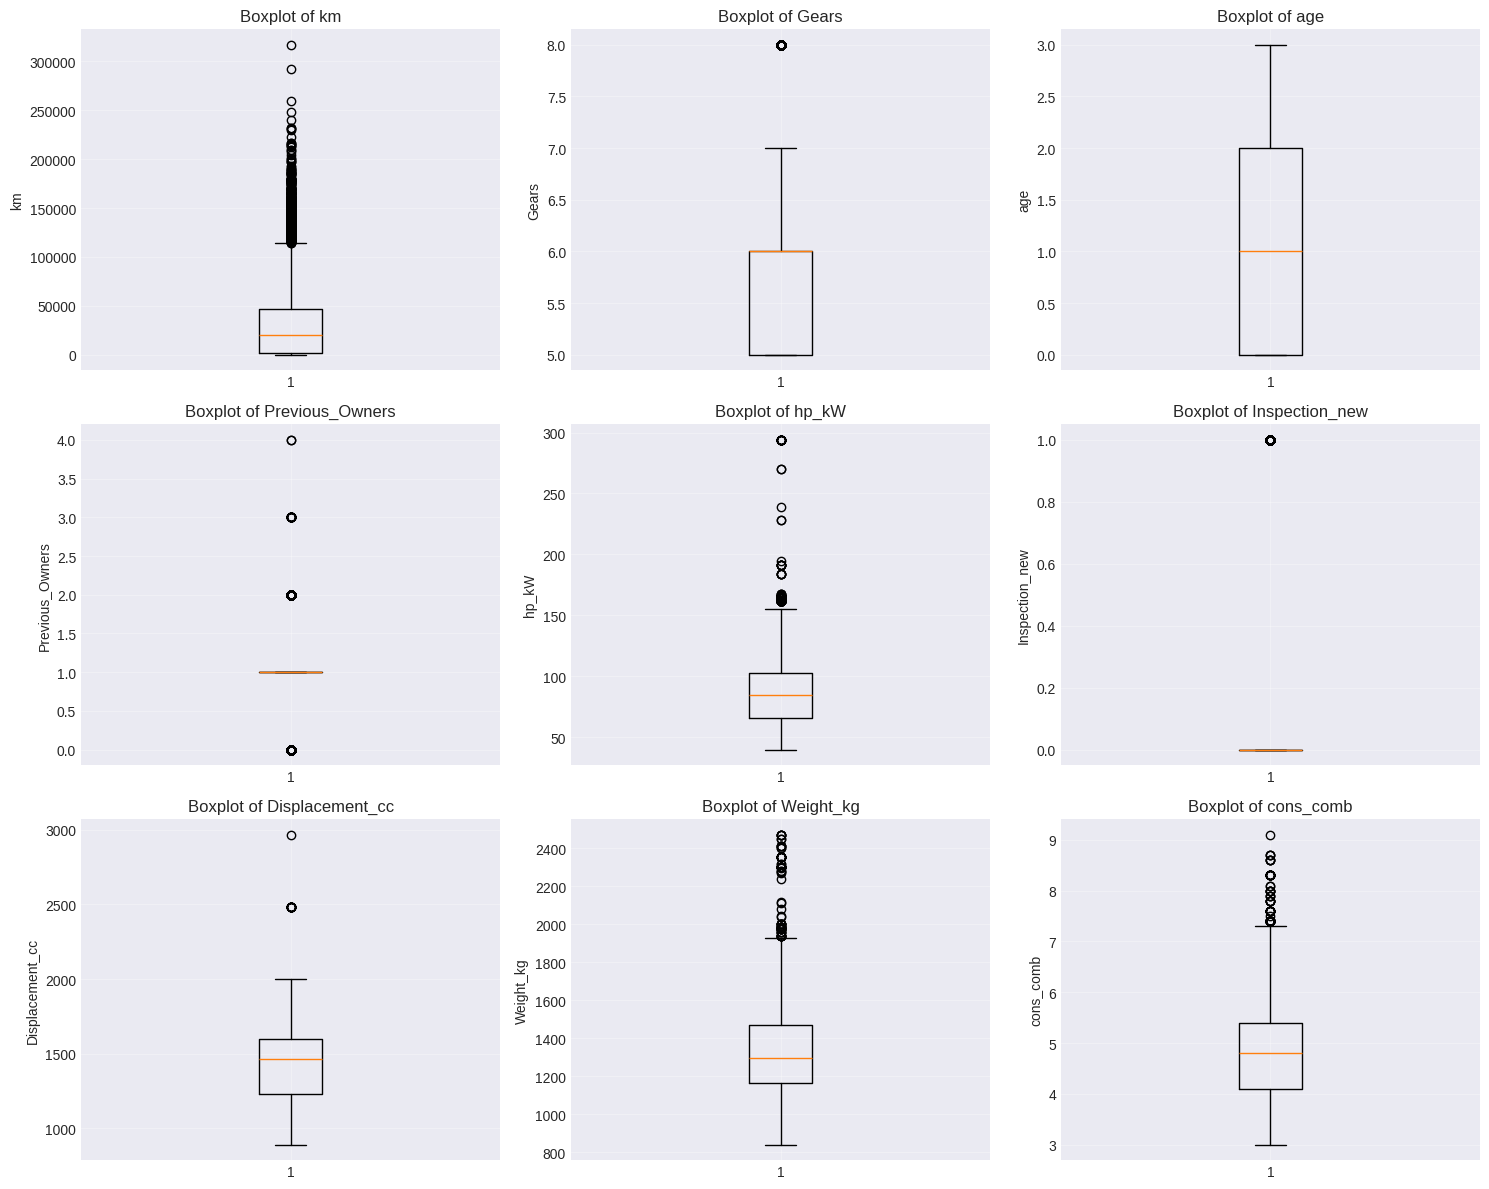

In [ ]:
# Outliers present in each column
def detect_outliers_iqr(df, columns):
    """Detect outliers using IQR method"""
    outliers_dict = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_dict[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

    return outliers_dict

# Detect outliers in numerical columns
outliers_info = detect_outliers_iqr(df, numerical_cols)

print("\nOutliers Summary:")
for col, info in outliers_info.items():
    print(f"\n{col}:")
    print(f"  Outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Lower bound: {info['lower_bound']:.2f}")
    print(f"  Upper bound: {info['upper_bound']:.2f}")

# Visualize outliers using boxplots
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=300, bbox_inches='tight')
print("\nOutlier identification completed")

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [ ]:
# Handle outliers

# Create a copy for comparison
df_before_outliers = df.copy()

# Method: Cap outliers at 1st and 99th percentile
for col in numerical_cols:
    percentile_1 = df[col].quantile(0.01)
    percentile_99 = df[col].quantile(0.99)

    # Cap the outliers
    df[col] = df[col].clip(lower=percentile_1, upper=percentile_99)

print("\nOutliers capped at 1st and 99th percentiles")

# Check outliers after handling
outliers_info_after = detect_outliers_iqr(df, numerical_cols)

print("\nOutliers After Handling:")
for col, info in outliers_info_after.items():
    print(f"{col}: {info['count']} outliers ({info['percentage']:.2f}%)")

print("\nOutliers handled successfully")


Outliers capped at 1st and 99th percentiles

Outliers After Handling:
km: 689 outliers (4.33%)
Gears: 225 outliers (1.41%)
age: 0 outliers (0.00%)
Previous_Owners: 1757 outliers (11.04%)
hp_kW: 361 outliers (2.27%)
Inspection_new: 3932 outliers (24.71%)
Displacement_cc: 0 outliers (0.00%)
Weight_kg: 0 outliers (0.00%)
cons_comb: 0 outliers (0.00%)

Outliers handled successfully


### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [ ]:
# Fix/create columns as needed

# Check for redundant columns
print("\nChecking for redundant features...")

# Drop 'price' if it exists (we're using log_price)
if 'price' in df.columns:
    df = df.drop('price', axis=1)
    print("Dropped original 'price' column (using log_price)")

# Check for columns with very low variance
low_variance_cols = []
for col in numerical_cols:
    if col in df.columns:
        if df[col].std() < 0.01:
            low_variance_cols.append(col)

if low_variance_cols:
    print(f"\nLow variance columns: {low_variance_cols}")
    df = df.drop(low_variance_cols, axis=1)
    numerical_cols = [col for col in numerical_cols if col not in low_variance_cols]

# Create new features if beneficial
# Example: Power to weight ratio
if 'hp_kW' in df.columns and 'Weight_kg' in df.columns:
    df['power_to_weight'] = df['hp_kW'] / df['Weight_kg']
    numerical_cols.append('power_to_weight')
    print("Created 'power_to_weight' feature")

# Age squared (non-linear relationship)
if 'age' in df.columns:
    df['age_squared'] = df['age'] ** 2
    numerical_cols.append('age_squared')
    print("Created 'age_squared' feature")

print("\nRedundant columns fixed and new features created")


Checking for redundant features...
Dropped original 'price' column (using log_price)
Created 'power_to_weight' feature
Created 'age_squared' feature

Redundant columns fixed and new features created


#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [ ]:
# Check unique values in each feature spec column

# Columns with lists of features
feature_list_cols = ['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']

# Function to extract unique features
def get_all_unique_features(df, columns):
    """Extract all unique features from list columns"""
    all_features = {}

    for col in columns:
        if col in df.columns:
            features_set = set()
            for val in df[col].dropna():
                if isinstance(val, str):
                    features = [f.strip() for f in val.split(',')]
                    features_set.update(features)
            all_features[col] = sorted(list(features_set))

    return all_features

# Get unique features
unique_features = get_all_unique_features(df, feature_list_cols)

for col, features in unique_features.items():
    print(f"\n{col} - Unique features ({len(features)}):")
    print(features[:10])  # Show first 10


Comfort_Convenience - Unique features (38):
['Air conditioning', 'Air suspension', 'Armrest', 'Automatic climate control', 'Auxiliary heating', 'Cruise control', 'Electric Starter', 'Electric tailgate', 'Electrical side mirrors', 'Electrically adjustable seats']

Entertainment_Media - Unique features (10):
['Bluetooth', 'CD player', 'Digital radio', 'Hands-free equipment', 'MP3', 'On-board computer', 'Radio', 'Sound system', 'Television', 'USB']

Extras - Unique features (17):
['Alloy wheels', 'Cab or rented Car', 'Catalytic Converter', 'Handicapped enabled', 'Right hand drive', 'Roof rack', 'Shift paddles', 'Ski bag', 'Sliding door', 'Sport package']

Safety_Security - Unique features (29):
['ABS', 'Adaptive Cruise Control', 'Adaptive headlights', 'Alarm system', 'Blind spot monitor', 'Central door lock', 'Central door lock with remote control', 'Daytime running lights', 'Driver drowsiness detection', 'Driver-side airbag']


Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [ ]:
# Drop features from df

# Create binary features for important ones
# Filter features that appear in at least 5% but not more than 95% of cars
important_features = []

for col in feature_list_cols:
    if col in df.columns:
        for feature in unique_features.get(col, []):
            # Count occurrences
            count = df[col].astype(str).str.contains(feature, case=False, na=False).sum()
            percentage = count / len(df) * 100

            # Keep features that are not too rare or too common
            if 5 <= percentage <= 95:
                feature_name = f"{col}_{feature.replace(' ', '_')}"
                df[feature_name] = df[col].astype(str).str.contains(feature, case=False, na=False).astype(int)
                important_features.append(feature_name)

print(f"\nCreated {len(important_features)} binary features from feature lists")

# Drop original feature list columns
df = df.drop(feature_list_cols, axis=1)
print(f"Dropped original feature list columns")


Created 71 binary features from feature lists
Dropped original feature list columns


#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [ ]:
# Encode features

# Update categorical columns list
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print(f"\nOriginal shape: {df.shape}")
print(f"After encoding: {df_encoded.shape}")
print(f"One-hot encoding completed")

# Update df
df = df_encoded


Original shape: (15915, 92)
After encoding: (15915, 103)
One-hot encoding completed


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [ ]:
# Split data

# Separate features and target
X = df.drop('log_price', axis=1)
y = df['log_price']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print("Data split completed")


Features shape: (15915, 102)
Target shape: (15915,)

Training set: (12732, 102)
Testing set: (3183, 102)
Data split completed


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [ ]:
# Scale features

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Features scaled using StandardScaler")
print(f"\nScaled Training set shape: {X_train_scaled.shape}")
print(f"Scaled Testing set shape: {X_test_scaled.shape}")

print("\n" + "="*80)
print("DATA PREPROCESSING COMPLETED")
print("="*80)
print("\nData is now ready for modeling!")
print(f"Total features: {X_train_scaled.shape[1]}")
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")

Features scaled using StandardScaler

Scaled Training set shape: (12732, 102)
Scaled Testing set shape: (3183, 102)

DATA PREPROCESSING COMPLETED

Data is now ready for modeling!
Total features: 102
Training samples: 12732
Testing samples: 3183


## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [ ]:
# Initialise and train model
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
# Evaluate the model's performance

def evaluate_model(y_true, y_pred, model_name, dataset_name):
    """Calculate and display evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} - {dataset_name} Performance:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Evaluate on both train and test sets
lr_train_metrics = evaluate_model(y_train, y_train_pred_lr, "Linear Regression", "Training")
lr_test_metrics = evaluate_model(y_test, y_test_pred_lr, "Linear Regression", "Testing")

print("\n✓ Baseline Linear Regression model trained and evaluated")


Linear Regression - Training Performance:
  MAE:  0.0774
  MSE:  0.0111
  RMSE: 0.1052
  R²:   0.9300

Linear Regression - Testing Performance:
  MAE:  0.0769
  MSE:  0.0106
  RMSE: 0.1030
  R²:   0.9336

✓ Baseline Linear Regression model trained and evaluated


#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

Linearity check completed


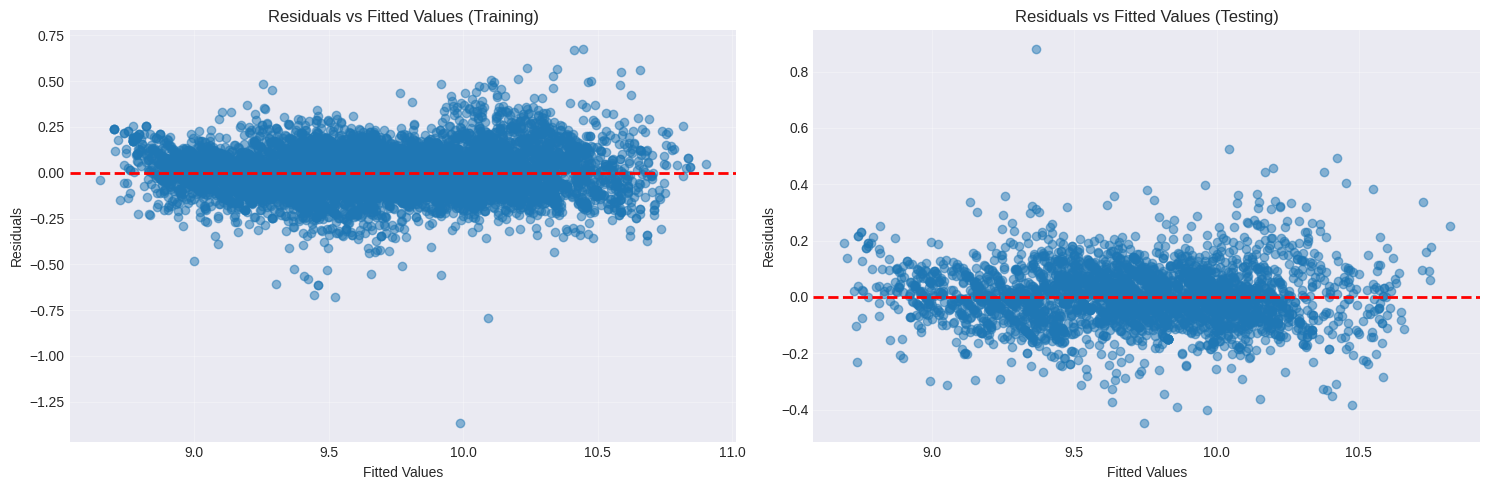

In [ ]:
# Linearity check: Plot residuals vs fitted values

# Calculate residuals
train_residuals = y_train - y_train_pred_lr
test_residuals = y_test - y_test_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_train_pred_lr, train_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values (Training)')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_pred_lr, test_residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted Values (Testing)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_vs_fitted.png', dpi=300, bbox_inches='tight')
print("Linearity check completed")

Check normality in residual distribution

Normality check completed


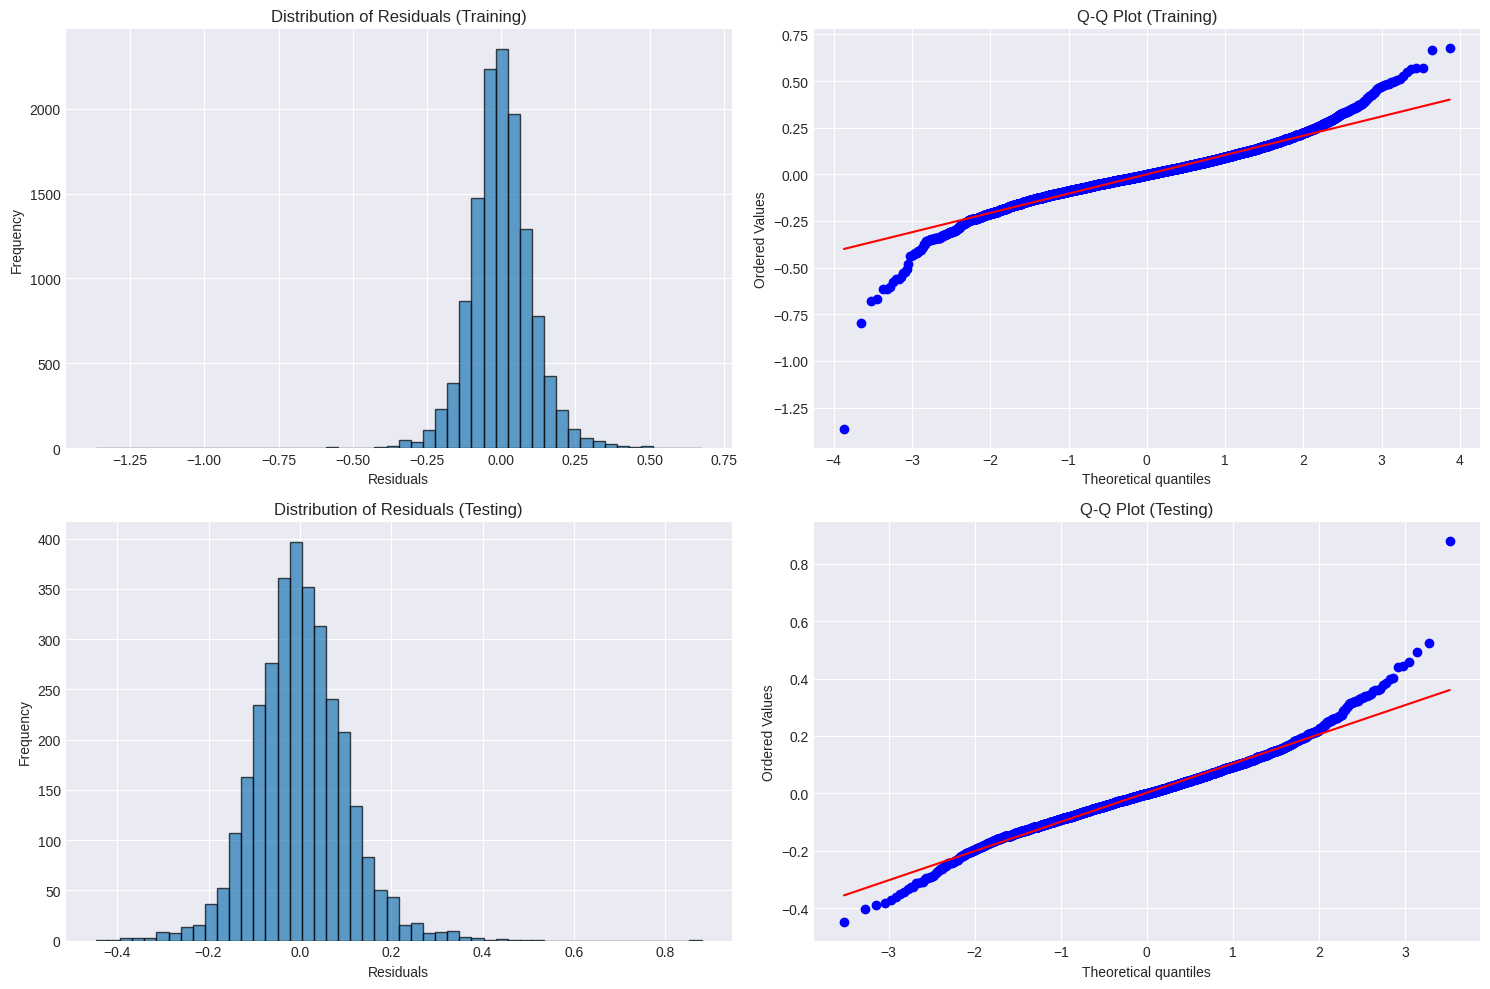

In [ ]:
# Check the normality of residuals by plotting their distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(train_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Residuals (Training)')
axes[0, 0].set_xlabel('Residuals')
axes[0, 0].set_ylabel('Frequency')

# Q-Q plot
stats.probplot(train_residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Training)')

axes[1, 0].hist(test_residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Residuals (Testing)')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')

stats.probplot(test_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Testing)')

plt.tight_layout()
plt.savefig('residual_normality.png', dpi=300, bbox_inches='tight')
print("Normality check completed")

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [ ]:
# Check for multicollinearity and handle

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i)
                    for i in range(X_train_scaled.shape[1])]

# Sort by VIF
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nTop 10 Features with Highest VIF:")
print(vif_data.head(10))

# Identify features with high VIF (>10)
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nFeatures with VIF > 10: {len(high_vif_features)}")

# Remove high VIF features
if high_vif_features:
    print(f"\nRemoving {len(high_vif_features)} features with high multicollinearity...")
    X_train_scaled_vif = X_train_scaled.drop(high_vif_features, axis=1)
    X_test_scaled_vif = X_test_scaled.drop(high_vif_features, axis=1)

    # Retrain model without high VIF features
    lr_model_vif = LinearRegression()
    lr_model_vif.fit(X_train_scaled_vif, y_train)

    y_train_pred_vif = lr_model_vif.predict(X_train_scaled_vif)
    y_test_pred_vif = lr_model_vif.predict(X_test_scaled_vif)

    print("\nModel Performance After Removing High VIF Features:")
    evaluate_model(y_train, y_train_pred_vif, "LR (Low VIF)", "Training")
    evaluate_model(y_test, y_test_pred_vif, "LR (Low VIF)", "Testing")

    # Update scaled datasets
    X_train_scaled = X_train_scaled_vif
    X_test_scaled = X_test_scaled_vif

print("\nMulticollinearity check and handling completed")


Top 10 Features with Highest VIF:
                                              Feature         VIF
4                                               hp_kW  187.292570
9                                     power_to_weight   95.428180
18  Comfort_Convenience_Electrically_heated_windsh...   79.104465
38                     Comfort_Convenience_Windshield   78.956997
7                                           Weight_kg   33.374333
2                                                 age   18.746639
10                                        age_squared   16.484800
88                          make_model_Renault Espace   11.205077
85                           make_model_Opel Insignia    7.516400
6                                     Displacement_cc    7.317257

Features with VIF > 10: 8

Removing 8 features with high multicollinearity...

Model Performance After Removing High VIF Features:

LR (Low VIF) - Training Performance:
  MAE:  0.0966
  MSE:  0.0163
  RMSE: 0.1277
  R²:   0.8970

LR (Low 

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Ridge regularisation
# Initial broad range of alphas
alphas_ridge_1 = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
print(f"\nInitial Alpha values: {alphas_ridge_1}")


Initial Alpha values: [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]


#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Applying Ridge regression

# Store results
ridge_results_1 = {
    'alpha': [],
    'train_score': [],
    'test_score': []
}

# Train Ridge models with different alphas
for alpha in alphas_ridge_1:
    ridge = Ridge(alpha=alpha, random_state=42)

    # Use cross-validation for better estimation
    train_scores = cross_val_score(ridge, X_train_scaled, y_train,
                                   cv=5, scoring='neg_mean_absolute_error')

    # Fit on full training set and evaluate on test
    ridge.fit(X_train_scaled, y_train)
    y_test_pred = ridge.predict(X_test_scaled)
    test_score = -mean_absolute_error(y_test, y_test_pred)

    ridge_results_1['alpha'].append(alpha)
    ridge_results_1['train_score'].append(train_scores.mean())
    ridge_results_1['test_score'].append(test_score)

# Convert to DataFrame
ridge_df_1 = pd.DataFrame(ridge_results_1)
print("\nRidge Results (First Pass):")
print(ridge_df_1)


Ridge Results (First Pass):
      alpha  train_score  test_score
0     0.001    -0.097383   -0.095717
1     0.010    -0.097383   -0.095717
2     0.100    -0.097382   -0.095717
3     1.000    -0.097381   -0.095715
4    10.000    -0.097371   -0.095697
5    50.000    -0.097356   -0.095636
6   100.000    -0.097408   -0.095607
7   500.000    -0.098994   -0.096390
8  1000.000    -0.101906   -0.098438


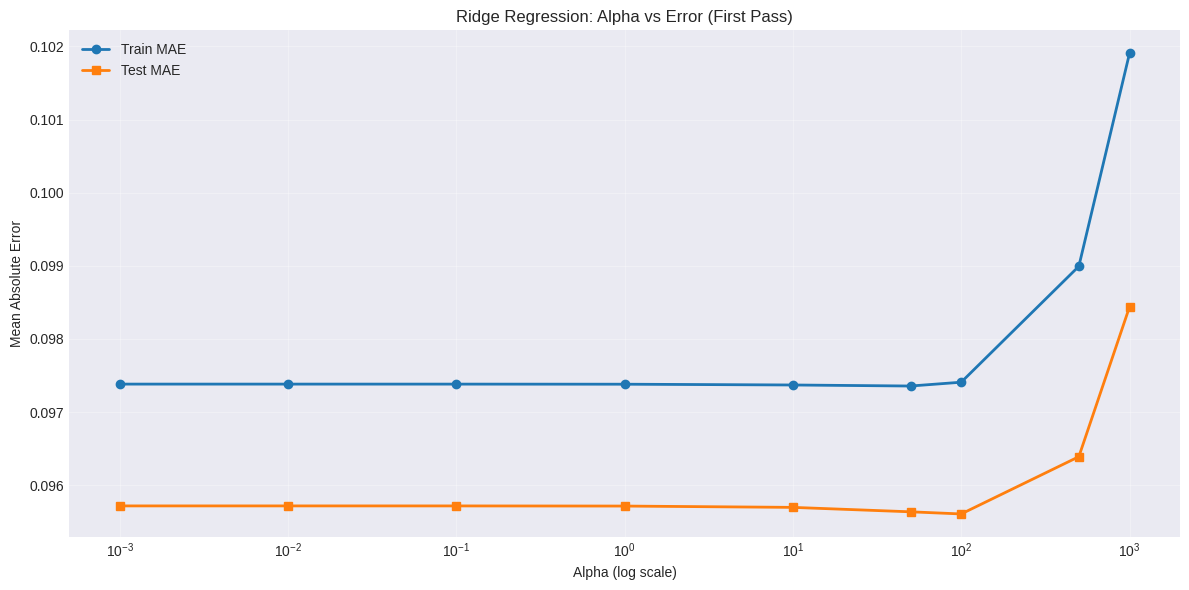

In [ ]:
# Plot train and test scores against alpha
plt.figure(figsize=(12, 6))
plt.plot(ridge_df_1['alpha'], -ridge_df_1['train_score'],
         marker='o', label='Train MAE', linewidth=2)
plt.plot(ridge_df_1['alpha'], -ridge_df_1['test_score'],
         marker='s', label='Test MAE', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean Absolute Error')
plt.title('Ridge Regression: Alpha vs Error (First Pass)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_alpha_tuning_pass1.png', dpi=300, bbox_inches='tight')

Find the best alpha value.

In [ ]:
# Best alpha value
# Find best alpha
best_idx_1 = ridge_df_1['test_score'].idxmax()
best_alpha_1 = ridge_df_1.loc[best_idx_1, 'alpha']
best_score_1 = ridge_df_1.loc[best_idx_1, 'test_score']

print(f"\nBest Alpha (Pass 1): {best_alpha_1}")
print(f"Best Score (Negative MAE): {best_score_1:.4f}")
print(f"Best MAE: {-best_score_1:.4f}")


# Best score (negative MAE)




Best Alpha (Pass 1): 100.0
Best Score (Negative MAE): -0.0956
Best MAE: 0.0956


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# Take a smaller range of alpha to test

# Create finer range around best alpha
if best_alpha_1 <= 0.01:
    alphas_ridge_2 = np.linspace(0.001, 0.1, 20)
elif best_alpha_1 <= 1:
    alphas_ridge_2 = np.linspace(best_alpha_1/5, best_alpha_1*5, 30)
elif best_alpha_1 <= 100:
    alphas_ridge_2 = np.linspace(best_alpha_1/2, best_alpha_1*2, 30)
else:
    alphas_ridge_2 = np.linspace(best_alpha_1/2, best_alpha_1*1.5, 30)

print(f"\nFine-tuning in range: [{alphas_ridge_2.min():.4f}, {alphas_ridge_2.max():.4f}]")

# Store results for fine-tuning
ridge_results_2 = {
    'alpha': [],
    'train_score': [],
    'test_score': []
}




Fine-tuning in range: [50.0000, 200.0000]


In [ ]:
# Applying Ridge regression
# Train Ridge models with finer alphas
for alpha in alphas_ridge_2:
    ridge = Ridge(alpha=alpha, random_state=42)
    train_scores = cross_val_score(ridge, X_train_scaled, y_train,
                                   cv=5, scoring='neg_mean_absolute_error')
    ridge.fit(X_train_scaled, y_train)
    y_test_pred = ridge.predict(X_test_scaled)
    test_score = -mean_absolute_error(y_test, y_test_pred)

    ridge_results_2['alpha'].append(alpha)
    ridge_results_2['train_score'].append(train_scores.mean())
    ridge_results_2['test_score'].append(test_score)

# Convert to DataFrame
ridge_df_2 = pd.DataFrame(ridge_results_2)

Plot the error-alpha graph again and find the actual optimal value for alpha.


Optimal Alpha (Ridge): 96.5517
Best Score (Negative MAE): -0.0956
Best MAE: 0.0956


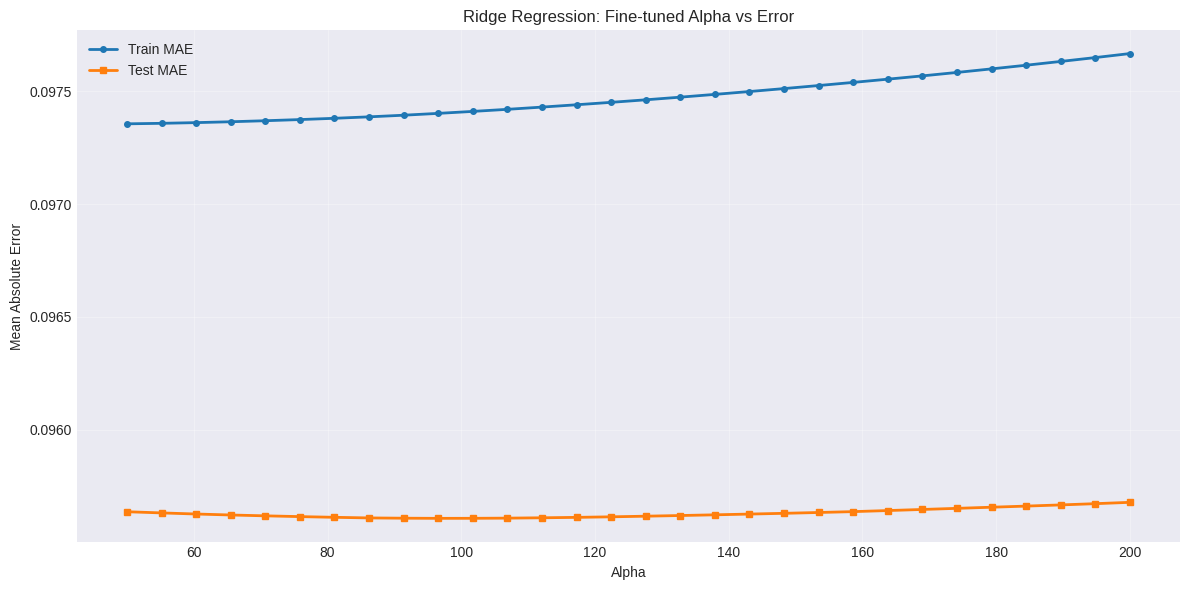

In [ ]:
# Plot train and test scores against alpha

# Plot refined results
plt.figure(figsize=(12, 6))
plt.plot(ridge_df_2['alpha'], -ridge_df_2['train_score'],
         marker='o', label='Train MAE', linewidth=2, markersize=4)
plt.plot(ridge_df_2['alpha'], -ridge_df_2['test_score'],
         marker='s', label='Test MAE', linewidth=2, markersize=4)
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Error')
plt.title('Ridge Regression: Fine-tuned Alpha vs Error')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_alpha_tuning_pass2.png', dpi=300, bbox_inches='tight')

# Best alpha value

# Find optimal alpha
best_idx_2 = ridge_df_2['test_score'].idxmax()
best_alpha_ridge = ridge_df_2.loc[best_idx_2, 'alpha']
best_score_ridge = ridge_df_2.loc[best_idx_2, 'test_score']

# Best score (negative MAE)

print(f"\nOptimal Alpha (Ridge): {best_alpha_ridge:.4f}")
print(f"Best Score (Negative MAE): {best_score_ridge:.4f}")
print(f"Best MAE: {-best_score_ridge:.4f}")

In [ ]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model

# Train final Ridge model with best alpha
ridge_final = Ridge(alpha=best_alpha_ridge, random_state=42)
ridge_final.fit(X_train_scaled, y_train)

# Get predictions
y_train_pred_ridge = ridge_final.predict(X_train_scaled)
y_test_pred_ridge = ridge_final.predict(X_test_scaled)

In [ ]:
# Show the coefficients for each feature

# Show coefficients
ridge_coef = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': ridge_final.coef_
})
ridge_coef = ridge_coef.reindex(ridge_coef['Coefficient'].abs().sort_values(ascending=False).index)

print("\nTop 10 Ridge Coefficients (by magnitude):")
print(ridge_coef.head(10))



Top 10 Ridge Coefficients (by magnitude):
                     Feature  Coefficient
77     make_model_Opel Corsa    -0.188755
0                         km    -0.149146
80   make_model_Renault Clio    -0.142268
76     make_model_Opel Astra    -0.080491
91       Gearing_Type_Manual    -0.059985
4            Displacement_cc     0.042972
5                  cons_comb     0.042162
84             body_type_Van     0.040169
78  make_model_Opel Insignia    -0.035554
75        make_model_Audi A3     0.035428


In [ ]:
# Evaluate the Ridge model on the test data
# Evaluate Ridge model

ridge_train_metrics = evaluate_model(y_train, y_train_pred_ridge, "Ridge", "Training")
ridge_test_metrics = evaluate_model(y_test, y_test_pred_ridge, "Ridge", "Testing")

print("\nRidge Regression completed")


Ridge - Training Performance:
  MAE:  0.0966
  MSE:  0.0163
  RMSE: 0.1278
  R²:   0.8968

Ridge - Testing Performance:
  MAE:  0.0956
  MSE:  0.0158
  RMSE: 0.1257
  R²:   0.9011

Ridge Regression completed


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Lasso regularisation

# Initial broad range of alphas for Lasso
alphas_lasso_1 = [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50]
print(f"\nInitial Alpha values: {alphas_lasso_1}")


Initial Alpha values: [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50]


#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Initialise Lasso regression model

# Store results
lasso_results_1 = {
    'alpha': [],
    'train_score': [],
    'test_score': [],
    'n_features': []
}

# Train Lasso models with different alphas
for alpha in alphas_lasso_1:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)

    train_scores = cross_val_score(lasso, X_train_scaled, y_train,
                                   cv=5, scoring='neg_mean_absolute_error')

    lasso.fit(X_train_scaled, y_train)
    y_test_pred = lasso.predict(X_test_scaled)
    test_score = -mean_absolute_error(y_test, y_test_pred)

    # Count non-zero coefficients
    n_features = np.sum(lasso.coef_ != 0)

    lasso_results_1['alpha'].append(alpha)
    lasso_results_1['train_score'].append(train_scores.mean())
    lasso_results_1['test_score'].append(test_score)
    lasso_results_1['n_features'].append(n_features)

# Convert to DataFrame
lasso_df_1 = pd.DataFrame(lasso_results_1)
print("\nLasso Results (First Pass):")
print(lasso_df_1)


Lasso Results (First Pass):
     alpha  train_score  test_score  n_features
0   0.0001    -0.097347   -0.095707          92
1   0.0010    -0.097470   -0.095939          79
2   0.0100    -0.104798   -0.102525          35
3   0.1000    -0.220358   -0.222570           8
4   1.0000    -0.318478   -0.321539           0
5   5.0000    -0.318478   -0.321539           0
6  10.0000    -0.318478   -0.321539           0
7  50.0000    -0.318478   -0.321539           0


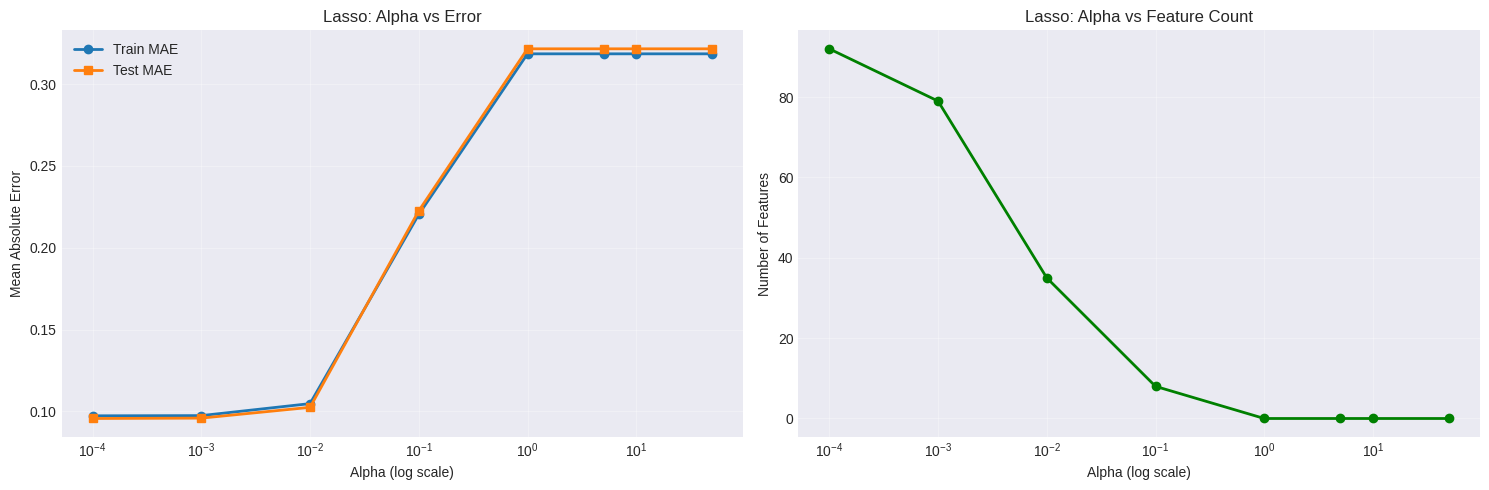

In [ ]:
# Plot train and test scores against alpha
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(lasso_df_1['alpha'], -lasso_df_1['train_score'],
             marker='o', label='Train MAE', linewidth=2)
axes[0].plot(lasso_df_1['alpha'], -lasso_df_1['test_score'],
             marker='s', label='Test MAE', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('Lasso: Alpha vs Error')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lasso_df_1['alpha'], lasso_df_1['n_features'],
             marker='o', linewidth=2, color='green')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Lasso: Alpha vs Feature Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_alpha_tuning_pass1.png', dpi=300, bbox_inches='tight')


In [ ]:
# Best alpha value
best_idx_lasso_1 = lasso_df_1['test_score'].idxmax()
best_alpha_lasso_1 = lasso_df_1.loc[best_idx_lasso_1, 'alpha']
best_score_lasso_1 = lasso_df_1.loc[best_idx_lasso_1, 'test_score']

print(f"\nBest Alpha (Pass 1): {best_alpha_lasso_1}")
print(f"Best Score (Negative MAE): {best_score_lasso_1:.4f}")
print(f"Features retained: {lasso_df_1.loc[best_idx_lasso_1, 'n_features']}")



Best Alpha (Pass 1): 0.0001
Best Score (Negative MAE): -0.0957
Features retained: 92


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# List of alphas to tune for Lasso regularization

# Create finer range around best alpha
if best_alpha_lasso_1 <= 0.01:
    alphas_lasso_2 = np.linspace(0.0001, 0.05, 30)
elif best_alpha_lasso_1 <= 1:
    alphas_lasso_2 = np.linspace(best_alpha_lasso_1/5, best_alpha_lasso_1*5, 30)
else:
    alphas_lasso_2 = np.linspace(best_alpha_lasso_1/2, best_alpha_lasso_1*2, 30)

print(f"\nFine-tuning in range: [{alphas_lasso_2.min():.4f}, {alphas_lasso_2.max():.4f}]")

# Store results for fine-tuning
lasso_results_2 = {
    'alpha': [],
    'train_score': [],
    'test_score': [],
    'n_features': []
}


Fine-tuning in range: [0.0001, 0.0500]


In [ ]:
# Tuning Lasso hyperparameters

# Train Lasso models with finer alphas
for alpha in alphas_lasso_2:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)

    train_scores = cross_val_score(lasso, X_train_scaled, y_train,
                                   cv=5, scoring='neg_mean_absolute_error')

    lasso.fit(X_train_scaled, y_train)
    y_test_pred = lasso.predict(X_test_scaled)
    test_score = -mean_absolute_error(y_test, y_test_pred)
    n_features = np.sum(lasso.coef_ != 0)

    lasso_results_2['alpha'].append(alpha)
    lasso_results_2['train_score'].append(train_scores.mean())
    lasso_results_2['test_score'].append(test_score)
    lasso_results_2['n_features'].append(n_features)

# Convert to DataFrame
lasso_df_2 = pd.DataFrame(lasso_results_2)



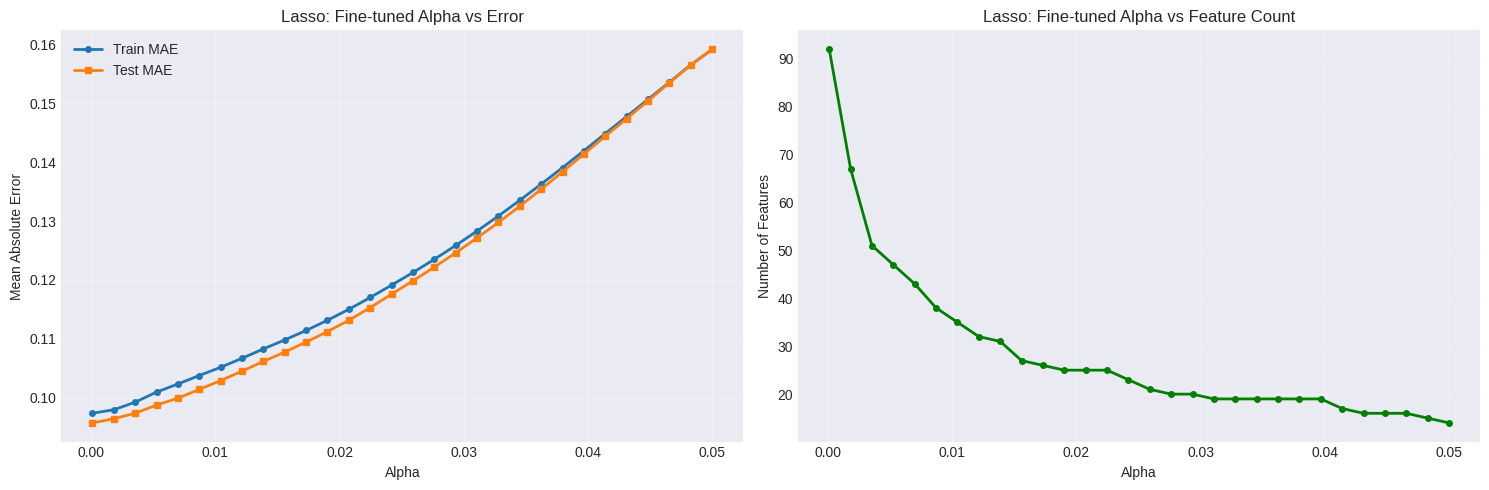

In [ ]:
# Plot train and test scores against alpha
# Plot refined results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(lasso_df_2['alpha'], -lasso_df_2['train_score'],
             marker='o', label='Train MAE', linewidth=2, markersize=4)
axes[0].plot(lasso_df_2['alpha'], -lasso_df_2['test_score'],
             marker='s', label='Test MAE', linewidth=2, markersize=4)
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('Lasso: Fine-tuned Alpha vs Error')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lasso_df_2['alpha'], lasso_df_2['n_features'],
             marker='o', linewidth=2, color='green', markersize=4)
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Number of Features')
axes[1].set_title('Lasso: Fine-tuned Alpha vs Feature Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_alpha_tuning_pass2.png', dpi=300, bbox_inches='tight')

In [ ]:
# Best alpha value
# Fit the Lasso model on scaled training data
lasso_final = Lasso(alpha=best_alpha_lasso, random_state=42, max_iter=10000)
lasso_final.fit(X_train_scaled, y_train)

best_idx_lasso_2 = lasso_df_2['test_score'].idxmax()
best_alpha_lasso = lasso_df_2.loc[best_idx_lasso_2, 'alpha']
best_score_lasso = lasso_df_2.loc[best_idx_lasso_2, 'test_score']
best_n_features = lasso_df_2.loc[best_idx_lasso_2, 'n_features']

# Get predictions
y_train_pred_lasso = lasso_final.predict(X_train_scaled)
y_test_pred_lasso = lasso_final.predict(X_test_scaled)

# Best score (negative MAE)



In [ ]:
# Set best alpha for Lasso regression


# Get the coefficients of the fitted model
print(f"\nOptimal Alpha (Lasso): {best_alpha_lasso:.4f}")
print(f"Best Score (Negative MAE): {best_score_lasso:.4f}")
print(f"Best MAE: {-best_score_lasso:.4f}")
print(f"Features retained: {int(best_n_features)}/{X_train_scaled.shape[1]}")


Optimal Alpha (Lasso): 0.0001
Best Score (Negative MAE): -0.0957
Best MAE: 0.0957
Features retained: 92/94


In [ ]:
# Check the coefficients for each feature
# Show coefficients
lasso_coef = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lasso_final.coef_
})
lasso_coef = lasso_coef.reindex(lasso_coef['Coefficient'].abs().sort_values(ascending=False).index)

print("\nTop 10 Lasso Coefficients (by magnitude):")
print(lasso_coef.head(10))

print(f"\nFeatures eliminated by Lasso: {np.sum(lasso_final.coef_ == 0)}")


Top 10 Lasso Coefficients (by magnitude):
                     Feature  Coefficient
77     make_model_Opel Corsa    -0.196992
0                         km    -0.150515
80   make_model_Renault Clio    -0.148975
76     make_model_Opel Astra    -0.086554
91       Gearing_Type_Manual    -0.060945
4            Displacement_cc     0.044878
5                  cons_comb     0.043887
78  make_model_Opel Insignia    -0.041094
84             body_type_Van     0.037384
75        make_model_Audi A3     0.033036

Features eliminated by Lasso: 2


In [ ]:
# Evaluate the Lasso model on the test data

lasso_train_metrics = evaluate_model(y_train, y_train_pred_lasso, "Lasso", "Training")
lasso_test_metrics = evaluate_model(y_test, y_test_pred_lasso, "Lasso", "Testing")

print("\n✓ Lasso Regression completed")


Lasso - Training Performance:
  MAE:  0.0965
  MSE:  0.0163
  RMSE: 0.1277
  R²:   0.8970

Lasso - Testing Performance:
  MAE:  0.0957
  MSE:  0.0158
  RMSE: 0.1256
  R²:   0.9013

✓ Lasso Regression completed


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.


Model Performance Comparison:
            Model Dataset      MAE     RMSE       R2
Linear Regression   Train 0.077429 0.105227 0.930024
Linear Regression    Test 0.076927 0.103007 0.933619
            Ridge   Train 0.096554 0.127788 0.896801
            Ridge    Test 0.095607 0.125701 0.901148
            Lasso   Train 0.096539 0.127684 0.896969
            Lasso    Test 0.095707 0.125634 0.901253

--------------------------------------------------------------------------------
OVERFITTING ANALYSIS (Train-Test Performance Gap)
--------------------------------------------------------------------------------

Linear Regression:
  R² Gap (Train - Test): -0.0036
  MAE Gap (Test - Train): -0.0005
  Status: Well generalized (low overfitting)

Ridge:
  R² Gap (Train - Test): -0.0043
  MAE Gap (Test - Train): -0.0009
  Status: Well generalized (low overfitting)

Lasso:
  R² Gap (Train - Test): -0.0043
  MAE Gap (Test - Train): -0.0008
  Status: Well generalized (low overfitting)

Model compar

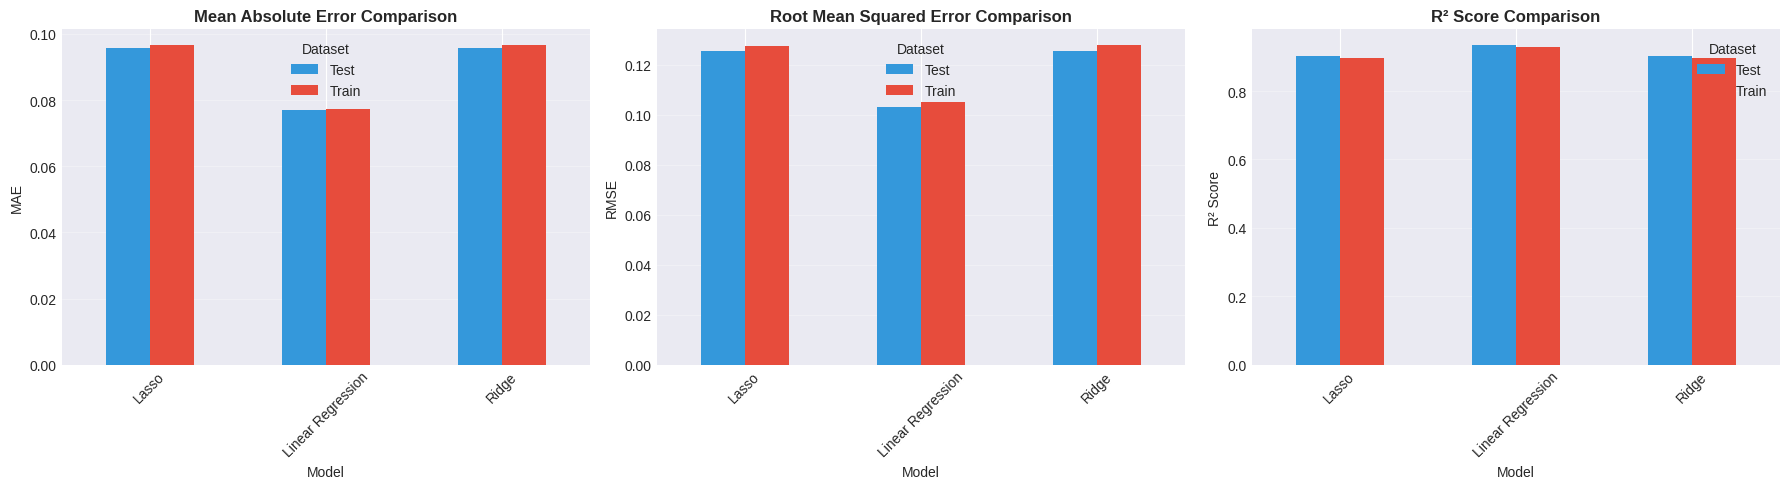

In [ ]:
# Compare metrics for each model

# Compile all metrics into a comparison DataFrame
comparison_data = {
    'Model': ['Linear Regression', 'Linear Regression', 'Ridge', 'Ridge', 'Lasso', 'Lasso'],
    'Dataset': ['Train', 'Test', 'Train', 'Test', 'Train', 'Test'],
    'MAE': [
        lr_train_metrics['MAE'], lr_test_metrics['MAE'],
        ridge_train_metrics['MAE'], ridge_test_metrics['MAE'],
        lasso_train_metrics['MAE'], lasso_test_metrics['MAE']
    ],
    'RMSE': [
        lr_train_metrics['RMSE'], lr_test_metrics['RMSE'],
        ridge_train_metrics['RMSE'], ridge_test_metrics['RMSE'],
        lasso_train_metrics['RMSE'], lasso_test_metrics['RMSE']
    ],
    'R2': [
        lr_train_metrics['R2'], lr_test_metrics['R2'],
        ridge_train_metrics['R2'], ridge_test_metrics['R2'],
        lasso_train_metrics['R2'], lasso_test_metrics['R2']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Calculate overfitting metrics (Train-Test gap)
print("\n" + "-"*80)
print("OVERFITTING ANALYSIS (Train-Test Performance Gap)")
print("-"*80)

models_list = ['Linear Regression', 'Ridge', 'Lasso']
for model in models_list:
    model_data = comparison_df[comparison_df['Model'] == model]
    train_r2 = model_data[model_data['Dataset'] == 'Train']['R2'].values[0]
    test_r2 = model_data[model_data['Dataset'] == 'Test']['R2'].values[0]
    r2_gap = train_r2 - test_r2

    train_mae = model_data[model_data['Dataset'] == 'Train']['MAE'].values[0]
    test_mae = model_data[model_data['Dataset'] == 'Test']['MAE'].values[0]
    mae_gap = test_mae - train_mae

    print(f"\n{model}:")
    print(f"  R² Gap (Train - Test): {r2_gap:.4f}")
    print(f"  MAE Gap (Test - Train): {mae_gap:.4f}")

    if r2_gap < 0.05 and mae_gap < 0.1:
        print(f"  Status: Well generalized (low overfitting)")
    elif r2_gap < 0.10 and mae_gap < 0.15:
        print(f"  Status: Moderate generalization")
    else:
        print(f"  Status: Poor generalization (significant overfitting)")

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE comparison
mae_data = comparison_df.pivot(index='Model', columns='Dataset', values='MAE')
mae_data.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Mean Absolute Error Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].set_xlabel('Model')
axes[0].legend(title='Dataset')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# RMSE comparison
rmse_data = comparison_df.pivot(index='Model', columns='Dataset', values='RMSE')
rmse_data.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Root Mean Squared Error Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')
axes[1].legend(title='Dataset')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
r2_data = comparison_df.pivot(index='Model', columns='Dataset', values='R2')
r2_data.plot(kind='bar', ax=axes[2], color=['#3498db', '#e74c3c'])
axes[2].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_xlabel('Model')
axes[2].legend(title='Dataset')
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=300, bbox_inches='tight')

print("\nModel comparison completed")

#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.


Feature count verification:
  X_train_scaled features: 94
  Ridge coefficients: 94
  Lasso coefficients: 94

Linear Regression has 102 coefficients
  Retraining Linear Regression on the same feature set as Ridge/Lasso...
Linear Regression retrained with 94 coefficients

Top 15 Features by Coefficient Magnitude:
                                  Feature  LR_Coefficient  Ridge_Coefficient  Lasso_Coefficient
                    make_model_Opel Corsa       -0.197790          -0.188755          -0.196992
                                       km       -0.150496          -0.149146          -0.150515
                  make_model_Renault Clio       -0.149629          -0.142268          -0.148975
                    make_model_Opel Astra       -0.087396          -0.080491          -0.086554
                      Gearing_Type_Manual       -0.060820          -0.059985          -0.060945
                          Displacement_cc        0.045400           0.042972           0.044878
              

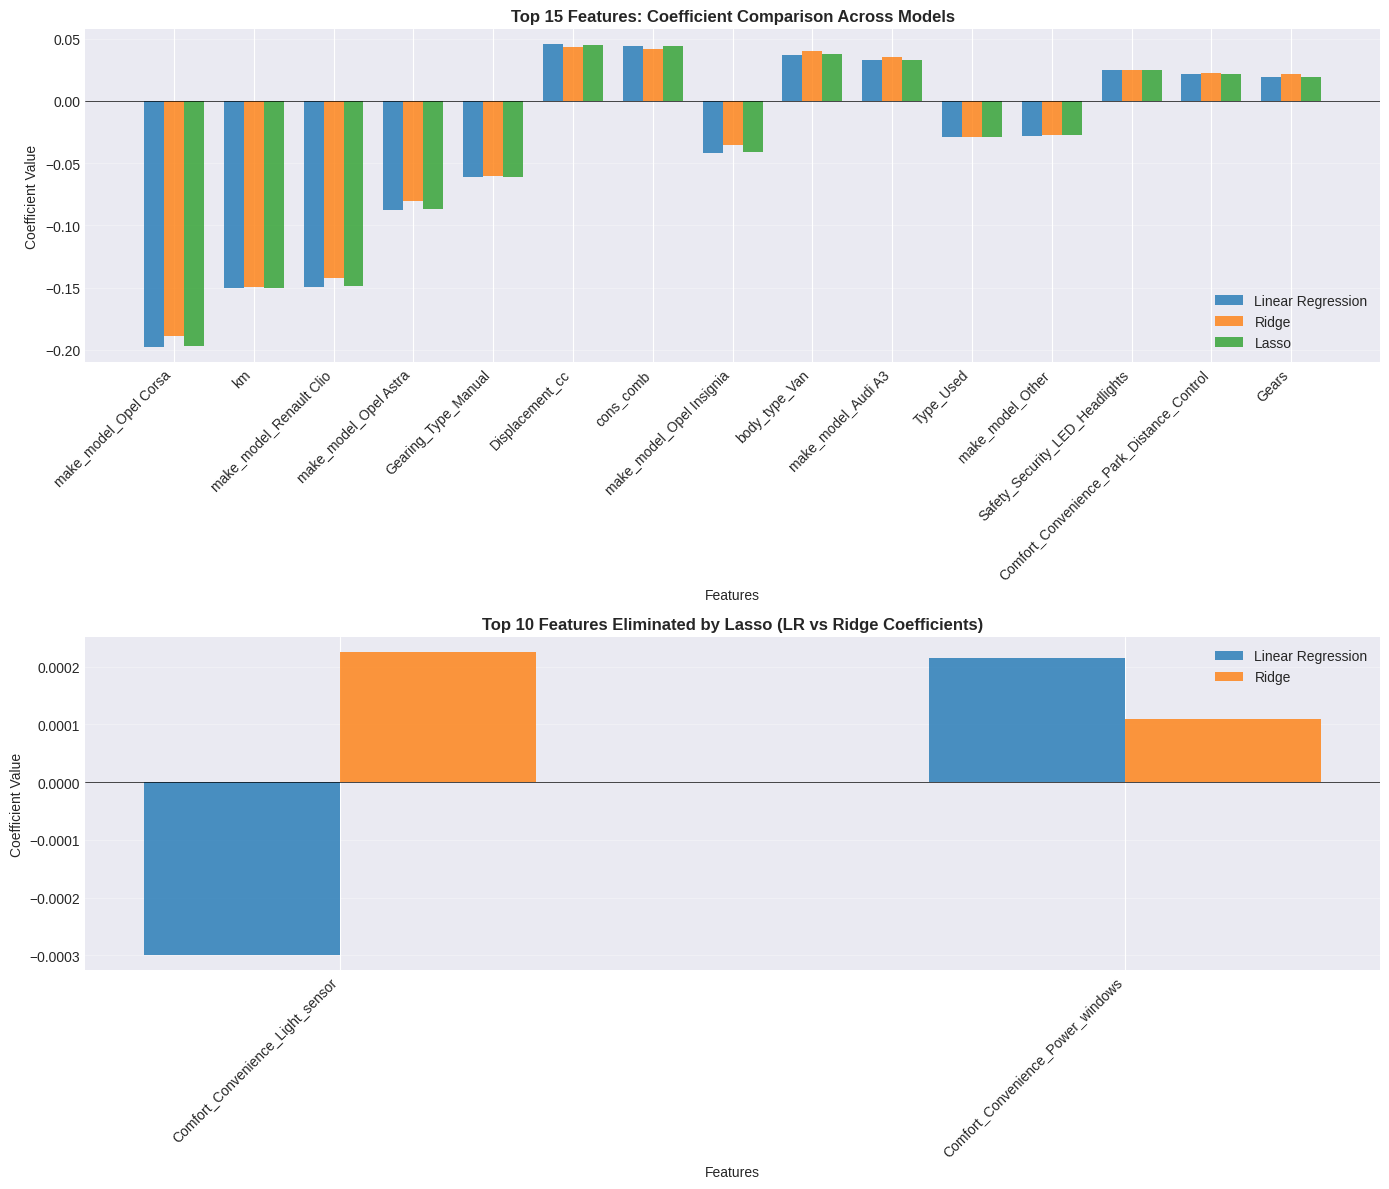


--------------------------------------------------------------------------------
COEFFICIENT SHRINKAGE ANALYSIS
--------------------------------------------------------------------------------

Average Absolute Coefficient:
  Linear Regression: 0.0155
  Ridge:            0.0151 (-2.28%)
  Lasso (non-zero): 0.0156 (+0.90%)


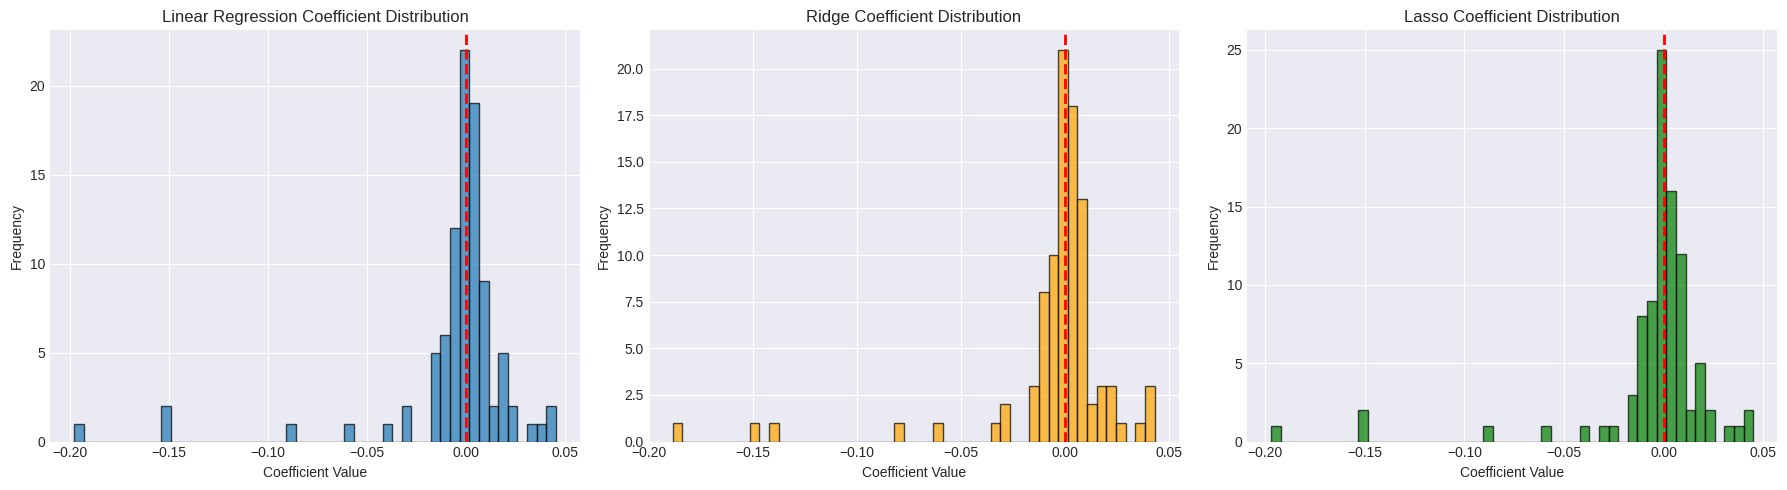


✓ Coefficient comparison completed


In [ ]:
# Compare highest coefficients and coefficients of eliminated features

# IMPORTANT: We need to use the same features for all three models
# Get the feature names that were used for Ridge and Lasso
feature_names = X_train_scaled.columns.tolist()

# Verify that all models have the same number of coefficients
print(f"\nFeature count verification:")
print(f"  X_train_scaled features: {len(feature_names)}")
print(f"  Ridge coefficients: {len(ridge_final.coef_)}")
print(f"  Lasso coefficients: {len(lasso_final.coef_)}")

# Check if Linear Regression needs to be retrained on the same feature set
if len(lr_model.coef_) != len(feature_names):
    print(f"\nLinear Regression has {len(lr_model.coef_)} coefficients")
    print(f"  Retraining Linear Regression on the same feature set as Ridge/Lasso...")

    # Retrain Linear Regression on the same features
    lr_model_final = LinearRegression()
    lr_model_final.fit(X_train_scaled, y_train)
    lr_coef_values = lr_model_final.coef_

    print(f"Linear Regression retrained with {len(lr_coef_values)} coefficients")
else:
    lr_coef_values = lr_model.coef_

# Now create the coefficient DataFrames with matching dimensions
lr_coef = pd.DataFrame({
    'Feature': feature_names,
    'LR_Coefficient': lr_coef_values
})

ridge_coef = pd.DataFrame({
    'Feature': feature_names,
    'Ridge_Coefficient': ridge_final.coef_
})

lasso_coef = pd.DataFrame({
    'Feature': feature_names,
    'Lasso_Coefficient': lasso_final.coef_
})

# Merge all coefficients
all_coef = lr_coef.merge(ridge_coef, on='Feature').merge(lasso_coef, on='Feature')
all_coef['LR_Abs'] = all_coef['LR_Coefficient'].abs()
all_coef['Ridge_Abs'] = all_coef['Ridge_Coefficient'].abs()
all_coef['Lasso_Abs'] = all_coef['Lasso_Coefficient'].abs()

# Sort by maximum absolute coefficient
all_coef['Max_Abs'] = all_coef[['LR_Abs', 'Ridge_Abs', 'Lasso_Abs']].max(axis=1)
all_coef = all_coef.sort_values('Max_Abs', ascending=False)

print("\nTop 15 Features by Coefficient Magnitude:")
print(all_coef[['Feature', 'LR_Coefficient', 'Ridge_Coefficient', 'Lasso_Coefficient']].head(15).to_string(index=False))

# Features eliminated by Lasso
eliminated_features = all_coef[all_coef['Lasso_Coefficient'] == 0]
print(f"\n\nFeatures Eliminated by Lasso: {len(eliminated_features)}")

if len(eliminated_features) > 0:
    print("\nTop 10 Eliminated Features (by Linear Regression coefficient):")
    eliminated_sorted = eliminated_features.sort_values('LR_Abs', ascending=False)
    print(eliminated_sorted[['Feature', 'LR_Coefficient', 'Ridge_Coefficient']].head(10).to_string(index=False))
else:
    print("Lasso retained all features")

# Visualize coefficient comparison for top features
top_15_features = all_coef.head(15)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Top coefficients comparison
x_pos = np.arange(len(top_15_features))
width = 0.25

axes[0].bar(x_pos - width, top_15_features['LR_Coefficient'], width,
           label='Linear Regression', alpha=0.8)
axes[0].bar(x_pos, top_15_features['Ridge_Coefficient'], width,
           label='Ridge', alpha=0.8)
axes[0].bar(x_pos + width, top_15_features['Lasso_Coefficient'], width,
           label='Lasso', alpha=0.8)

axes[0].set_xlabel('Features')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Top 15 Features: Coefficient Comparison Across Models',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(top_15_features['Feature'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: Eliminated features (comparing LR and Ridge coefficients)
if len(eliminated_features) > 0:
    top_eliminated = eliminated_sorted.head(10)
    x_pos_elim = np.arange(len(top_eliminated))

    axes[1].bar(x_pos_elim - width/2, top_eliminated['LR_Coefficient'], width,
               label='Linear Regression', alpha=0.8)
    axes[1].bar(x_pos_elim + width/2, top_eliminated['Ridge_Coefficient'], width,
               label='Ridge', alpha=0.8)

    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Coefficient Value')
    axes[1].set_title('Top 10 Features Eliminated by Lasso (LR vs Ridge Coefficients)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xticks(x_pos_elim)
    axes[1].set_xticklabels(top_eliminated['Feature'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
else:
    axes[1].text(0.5, 0.5, 'No features eliminated by Lasso',
                ha='center', va='center', fontsize=14)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('coefficient_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Coefficient shrinkage analysis
print("\n" + "-"*80)
print("COEFFICIENT SHRINKAGE ANALYSIS")
print("-"*80)

# Calculate average shrinkage
lr_mean_abs = all_coef['LR_Abs'].mean()
ridge_mean_abs = all_coef['Ridge_Abs'].mean()
lasso_nonzero = all_coef[all_coef['Lasso_Coefficient'] != 0]
if len(lasso_nonzero) > 0:
    lasso_mean_abs = lasso_nonzero['Lasso_Abs'].mean()
else:
    lasso_mean_abs = 0

print(f"\nAverage Absolute Coefficient:")
print(f"  Linear Regression: {lr_mean_abs:.4f}")
print(f"  Ridge:            {ridge_mean_abs:.4f} ({(ridge_mean_abs/lr_mean_abs - 1)*100:+.2f}%)")
if lasso_mean_abs > 0:
    print(f"  Lasso (non-zero): {lasso_mean_abs:.4f} ({(lasso_mean_abs/lr_mean_abs - 1)*100:+.2f}%)")
else:
    print(f"  Lasso (non-zero): N/A (all coefficients are zero)")

# Coefficient distribution plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_coef['LR_Coefficient'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Linear Regression Coefficient Distribution')
axes[0].set_xlabel('Coefficient Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[1].hist(all_coef['Ridge_Coefficient'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Ridge Coefficient Distribution')
axes[1].set_xlabel('Coefficient Value')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[2].hist(all_coef['Lasso_Coefficient'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Lasso Coefficient Distribution')
axes[2].set_xlabel('Coefficient Value')
axes[2].set_ylabel('Frequency')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.savefig('coefficient_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCoefficient comparison completed")

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>